# Hyperspectral SAE Analysis

### Cells 1-5 assume run_hsi_sae_pipeline.sh has been run

Consolidated notebook for:
1. Computing sparse codes from SAE models
2. Visualizing atoms (transport maps & target PDFs)
3. Computing and evaluating reconstructions

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'SAE.py').exists():
    REPO_ROOT = REPO_ROOT.parent

def repo_path(path):
    path = Path(path)
    return path if path.is_absolute() else REPO_ROOT / path

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
HSI_PIPELINE_DIR = REPO_ROOT / 'hsi' / 'pipeline'
if str(HSI_PIPELINE_DIR) not in sys.path:
    sys.path.insert(0, str(HSI_PIPELINE_DIR))
LLM_ANALYSIS_DIR = REPO_ROOT / 'llm' / 'analysis'
if str(LLM_ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(LLM_ANALYSIS_DIR))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA

import SAE
from SAE_analysis_functions import *
from plotting_tools import *
from brenier_embedding_functions import *

/usr/local/Caskroom/miniconda/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Architecture registry ──
ARCH_REGISTRY = {
    "TopKAE":              TopKAE,
    "topk":                TopKAE,
    "JumpReLU":            JumpReLUAE,
    "GatedSAE":            GatedSAE,
    "ReLUAE":              ReLUAE,
    "TopKAE_monotone":     TopKAE_monotone,
    "JumpReLUAE_monotone": JumpReLUAE_monotone,
    "ReLUAE_monotone":     ReLUAE_monotone,
}

SAE_PARAMETERS = {
    'JUMPRELUAE_10_1e-2_mon': {
        'architecture': 'JumpReLUAE_monotone',
        'l1': '1e-2',
        'lr': 1e-5,
        'hidden_dim': 10,
        'top_K': 0,
    },
    'JUMPRELUAE_10_5e-1_mon': {
        'architecture': 'JumpReLUAE_monotone',
        'l1': '5e-1',
        'lr': 1e-5,
        'hidden_dim': 10,
        'top_K': 0,
    },
     'JUMPRELUAE_10_1e-8_mon': {
        'architecture': 'JumpReLUAE_monotone',
        'l1': '1e-8',
        'lr': 1e-5,
        'hidden_dim': 10,
        'top_K': 0,
    },
}

# ── Paths ──
DATA_DIR       = repo_path('datasets/hsi_data/pavia')
POTENTIAL_PT   = DATA_DIR / 'transport_maps' / 'pavia_cube.pt'
ORIGINAL_PT    = DATA_DIR / 'data' / 'pavia_cube.pt'
SAE_ROOT       = DATA_DIR / 'SAE_params' / 'transport_maps' / 'unreg' / 'seed_0'
INPUT_DIM      = 102
DEVICE         = 'cpu'

RESULTS_DIR    = repo_path('hsi/results')
SWEEP_CSVS     = {
    'drop_random': RESULTS_DIR / 'drop_random' / 'df_drop_random_BEST.csv',
    'drop_contiguous': RESULTS_DIR / 'drop_contiguous' / 'df_drop_contiguous_BEST.csv',
    'log_warp': RESULTS_DIR / 'log_warp' / 'df_log_warp_BEST.csv',
}
SWEEP_PLOTS    = {
    'drop_random': RESULTS_DIR / 'drop_random' / 'robustness_comparison.png',
    'drop_contiguous': RESULTS_DIR / 'drop_contiguous' / 'robustness_comparison.png',
    'log_warp': RESULTS_DIR / 'log_warp' / 'robustness_comparison_logscale.png',
}


In [3]:
# ── Model loading (single entry point) ──

def load_model(architecture, hidden_dim, model_path, top_k=None, device=DEVICE):
    """Instantiate an SAE, load weights, return in eval mode."""
    cls = ARCH_REGISTRY[architecture]
    model = (cls(INPUT_DIM, hidden_dim, top_k=top_k) if cls in (TopKAE, TopKAE_monotone)
             else cls(INPUT_DIM, hidden_dim))
    model = model.to(device)
    state = torch.load(model_path, map_location=device)
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    model.load_state_dict(state, strict=True)
    model.eval()
    return model


def model_path_for(key):
    """Return the checkpoint path for a given SAE_PARAMETERS key."""
    return SAE_ROOT / key / 'sparse_ae.pt'


def get_atoms(model):
    """Extract atom matrix (K, m) as numpy float64."""
    with torch.no_grad():
        return model.atoms().detach().cpu().numpy().astype(np.float64)

In [4]:
# ── Atom → density helpers ──

def normalize_inv_cdf(T, eps=1e-12):
    """Shift to start at 0, scale to end at 1, enforce monotonicity."""
    T = T - T[0]
    T = T / (T[-1] if abs(T[-1]) > eps else eps)
    return np.maximum.accumulate(T)



def fd_density_from_inv_cdf(inv_cdf, eps=1e-12):
    """Finite-difference density from a monotone inverse-CDF.

    Uses central differences in the interior and one-sided differences
    at the boundaries, so the output lives on the same m-point grid
    as the input (no midpoint shift).
    """
    T = np.maximum.accumulate(np.asarray(inv_cdf, dtype=np.float64))
    m = len(T)
    dp = 1.0 / (m - 1)

    # Central differences (interior) + one-sided (boundaries)
    dT = np.empty(m)
    dT[1:-1] = (T[2:] - T[:-2]) / 2.0
    dT[0]    = T[1] - T[0]
    dT[-1]   = T[-1] - T[-2]
    dT = np.maximum(dT, eps)

    pdf = dp / dT
    area = np.trapz(pdf, T)
    if area > 0:
        pdf /= area
    return T, pdf


def kde_density_from_inv_cdf(inv_cdf, n_samples=20000, x_grid=None, bandwidth=0.05):
    """KDE-based density estimate from an inverse-CDF vector."""
    inv_cdf = np.asarray(inv_cdf, dtype=np.float64)
    p_grid = np.linspace(0.0, 1.0, len(inv_cdf))
    u = np.random.uniform(0.0, 1.0, n_samples)
    samples = np.interp(u, p_grid, inv_cdf)
    if x_grid is None:
        x_grid = np.linspace(inv_cdf.min(), inv_cdf.max(), 200)
    kde = stats.gaussian_kde(samples)
    kde.set_bandwidth(bandwidth)
    density = kde(x_grid)
    density /= np.trapz(density, x_grid)
    return samples, x_grid, density

In [5]:
# ── Synthesis / reconstruction ──

def synthesis_monotone(x, z, model, *, start_at_zero=True):
    """
    Reconstruct x from codes z using a pre-loaded monotone model.
    Returns (xhat, per-pixel MSE).
    """
    with torch.no_grad():
        A = model.atoms()
        x = x.to(A.device, dtype=A.dtype)
        z = z.to(A.device, dtype=A.dtype)
        xhat = z @ A
        if start_at_zero:
            xhat = xhat - xhat[..., :1]
        mse = ((xhat - x) ** 2).mean(dim=-1)
    return xhat.cpu(), mse.cpu()


def compute_mu_sigma(data_tensor, eps=1e-6):
    """Mean & std across dim=0, shape [1, D]."""
    data_tensor = data_tensor.float()
    mu    = data_tensor.mean(dim=0, keepdim=True)
    sigma = data_tensor.std(dim=0, keepdim=True).clamp_min(eps)
    return mu, sigma

## 2. Load Data & Encode

In [6]:
potential_cube = torch.load(POTENTIAL_PT)['cube']
og_cube        = torch.load(ORIGINAL_PT)
mu, sigma      = compute_mu_sigma(potential_cube)

# Encode all models
full_code_dict = {}
for key, cfg in SAE_PARAMETERS.items():
    print(f'Encoding {key} ...')
    codes = sae_encode_potential_batch(
        potential_cube,
        model_path_for(key),
        cfg['architecture'],
        INPUT_DIM,
        cfg['hidden_dim'],
        cfg['top_K'],
        device=DEVICE,
        batch_size=1024,
    )
    full_code_dict[key] = codes
    print(f'  → shape {codes.shape}')

Encoding JUMPRELUAE_10_1e-2_mon ...
  → shape torch.Size([1096, 715, 10])
Encoding JUMPRELUAE_10_5e-1_mon ...
  → shape torch.Size([1096, 715, 10])
Encoding JUMPRELUAE_10_1e-8_mon ...
  → shape torch.Size([1096, 715, 10])


## 4. Visualize Atoms

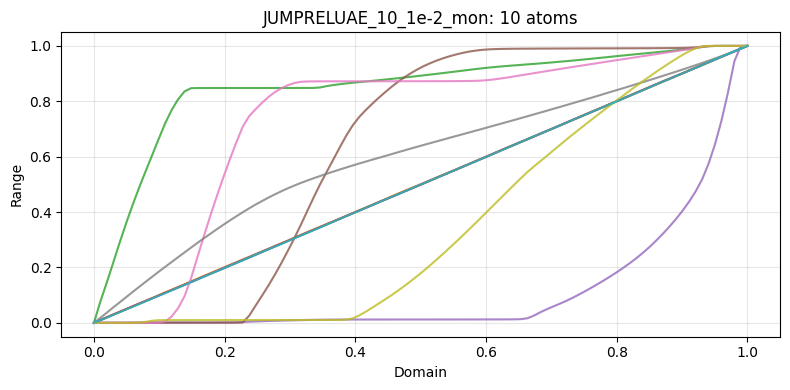

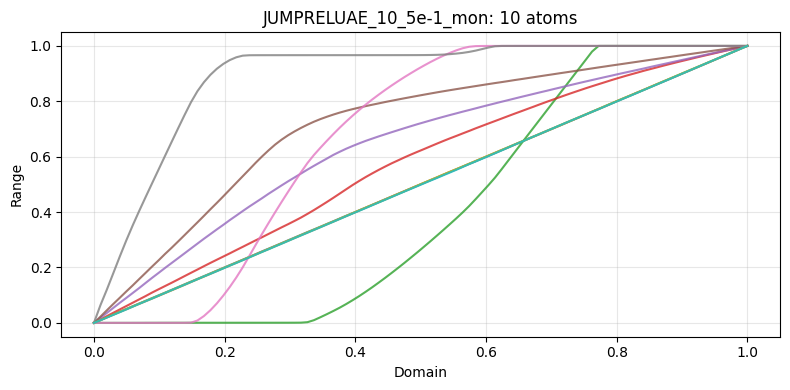

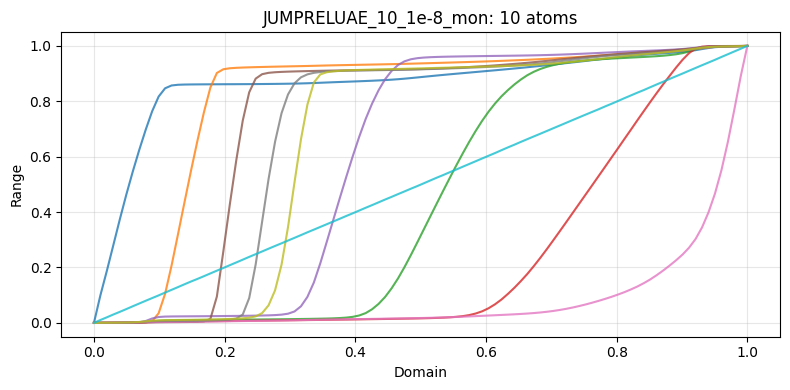

In [7]:
def plot_atoms_overlay(key, indices=None, normalize=True, alpha=0.5):
    """Overlay selected (or all) atom transport maps for a given model key."""
    cfg = SAE_PARAMETERS[key]
    model = load_model(cfg['architecture'], cfg['hidden_dim'], model_path_for(key),
                       top_k=cfg.get('top_K'))
    A = get_atoms(model)
    k, m = A.shape
    x = np.linspace(0, 1, m)
    atom_indices = range(k) if indices is None else [int(i) for i in indices]

    fig, ax = plt.subplots(figsize=(8, 4))
    for i in atom_indices:
        y = normalize_inv_cdf(A[i]) if normalize else A[i]
        ax.plot(x, y, alpha=alpha)
    ax.set(xlabel='Domain', ylabel='Range',
           title=f'{key}: {len(atom_indices)} atoms')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


# Example: overlay all atoms for each model
for key in SAE_PARAMETERS:
    plot_atoms_overlay(key, normalize=True, alpha=0.8)
    plt.show()

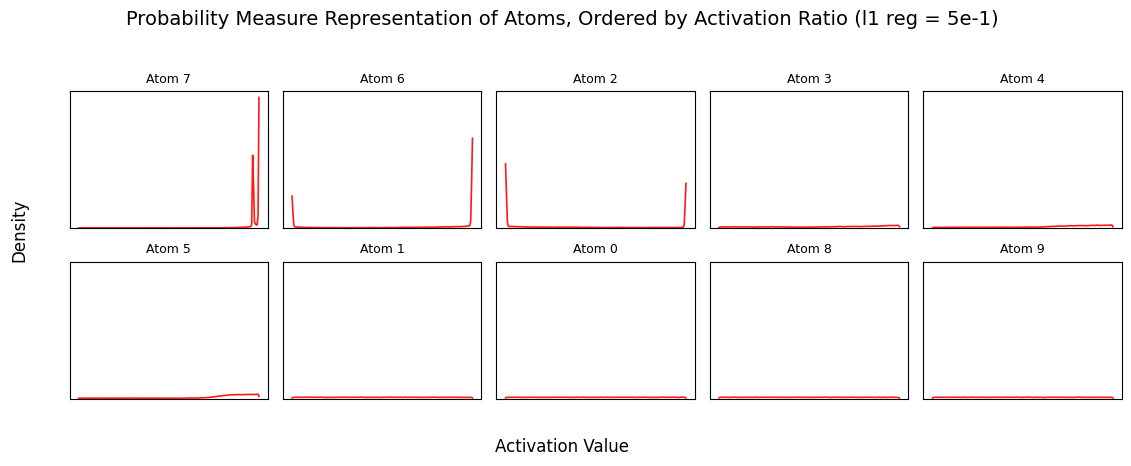

In [8]:
def plot_atom_density_grid(key, atom_indices, bandwidth=0.01, 
                           n_samples=40000, title=None):
    """
    Fixed 2x5 grid of per-atom density subplots.
    Returns: (fig, extracted_pdfs)
    """
    # Force a 2x5 configuration
    n_rows, n_cols = 2, 5
    max_plots = n_rows * n_cols
    
    # Take only the first 10 indices provided
    atom_indices = [int(i) for i in atom_indices[:max_plots]]
    
    cfg = SAE_PARAMETERS[key]
    model = load_model(cfg['architecture'], cfg['hidden_dim'], model_path_for(key),
                       top_k=cfg.get('top_K'))
    A = get_atoms(model)

    extracted_pdfs = {}
    n = len(atom_indices)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.3 * n_cols, 2.3 * n_rows),
                             sharex=True, sharey=True)
    axes = np.array(axes).flatten()
    fig.suptitle(title if title else f"{key} (KDE)", fontsize=14) 

    # --- Data Processing ---
    all_kde_data = []
    for idx in atom_indices:
        inv_cdf = normalize_inv_cdf(A[idx])
        
        # Compute KDE
        _, x_kde, pdf_kde = kde_density_from_inv_cdf(inv_cdf, n_samples=n_samples,
                                                     bandwidth=bandwidth)
        
        all_kde_data.append((x_kde, pdf_kde))
        extracted_pdfs[idx] = {
            'x': x_kde,
            'pdf': pdf_kde
        }

    # Set consistent y-limit based on the highest peak in this specific batch
    ymax = max(pdf.max() for _, pdf in all_kde_data) * 1.05

    # --- Plotting ---
    for i in range(len(axes)):
        ax = axes[i]
        if i < n:
            idx = atom_indices[i]
            x_kde, pdf_kde = all_kde_data[i]
            
            ax.plot(x_kde, pdf_kde, color='red', lw=1.2, alpha=0.9)
            ax.set_ylim(0, ymax)
            ax.set_title(f'Atom {idx}', fontsize=9)
        else:
            # Hide empty subplots if fewer than 10 indices were passed
            ax.axis('off')
            
        ax.set_xticks([])
        ax.set_yticks([])

    fig.supxlabel('Activation Value'); fig.supylabel('Density')
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
    
    if title:
        out_dir = repo_path('hyperspec_images')
        out_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_dir / f"atoms_kde_{title.replace(' ', '_')}.png")
    
    return fig, extracted_pdfs

ANALYSIS_KEY = 'JUMPRELUAE_10_5e-1_mon'   # <-- change this to switch models

cfg = SAE_PARAMETERS[ANALYSIS_KEY]
codes_3d = full_code_dict[ANALYSIS_KEY]
a, b, c  = codes_3d.shape
flat_codes = codes_3d.reshape(a * b, c)

# Usage statistics
usage = flat_codes.sum(dim=0)
usage_sorted, idx_sorted = torch.sort(usage, descending=True)
y = usage_sorted.cpu().numpy()
x = np.arange(1, len(y) + 1)


# Example: top-usage atoms grid
top_n = min(40, cfg['hidden_dim'])
_, top_idx = torch.topk(usage, top_n)
fig,atoms=plot_atom_density_grid(ANALYSIS_KEY, top_idx,title=f'Probability Measure Representation of Atoms, Ordered by Activation Ratio (l1 reg = {cfg["l1"]})')
plt.show()

In [9]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

def load_H(nmf_path, rank=None):
    p = os.path.expanduser(nmf_path)
    if os.path.isdir(p):
        files = glob.glob(os.path.join(p, "*.npz"))
        if not files:
            raise FileNotFoundError(f"no .npz files in {p}")
        if rank is not None:
            cand = [f for f in files if f"rank_{rank}" in os.path.basename(f) or f"r{rank}" in os.path.basename(f)]
            if cand: files = cand
        p = max(files, key=os.path.getmtime)

    z = np.load(p, allow_pickle=True)
    for k in ("H", "components", "components_"):
        if k in z:
            return np.asarray(z[k], dtype=np.float64), p
    raise KeyError(f"no H/components in {p}; keys={list(z.keys())}")

def plot_nmf_rows_grid(nmf_path, row_indices=None, rank=None,
                      n_cols=6, title=None, normalize_rows=False,
                      sharey=True, savepath=None):
    """
    Plot rows of NMF matrix H (K,D) as 1-D signals in a grid.
    """
    H, src = load_H(nmf_path, rank=rank)
    K, D = H.shape

    if row_indices is None:
        row_indices = list(range(K))
    row_indices = [int(i) for i in row_indices]
    for i in row_indices:
        if i < 0 or i >= K:
            raise ValueError(f"row index {i} out of range (K={K})")

    n = len(row_indices)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.3*n_cols, 2.3*n_rows),
                             sharex=True, sharey=sharey)
    axes = np.array(axes).flatten()

    fig.suptitle(title or f"NMF H rows: {os.path.basename(src)}", fontsize=14)

    ymax = 0.0
    rows = []
    for idx in row_indices:
        y = H[idx].copy()
        y = np.clip(y, 0, None)  # enforce nonneg visually
        if normalize_rows:
            s = y.sum()
            if s > 0: y = y / s
        rows.append(y)
        ymax = max(ymax, float(y.max()))

    x = np.arange(D)
    for a, idx, y in zip(axes, row_indices, rows):
        a.plot(x, y, lw=1.0)
        a.set_title(f"Row {idx}", fontsize=9)
        a.set_xticks([]); a.set_yticks([])
        a.set_ylim(0, ymax * 1.02 if ymax > 0 else 1.0)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.supxlabel("band index"); fig.supylabel("value")
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])

    if savepath:
        os.makedirs(os.path.dirname(savepath) or ".", exist_ok=True)
        plt.savefig(savepath, dpi=200)

    return fig, src

# Optional NMF comparison. This is skipped unless ./nmf_dicts exists.
nmf_dir = repo_path('nmf_dicts')
if nmf_dir.exists():
    fig, src = plot_nmf_rows_grid(nmf_dir, rank=10, row_indices=range(10),
                                  normalize_rows=True,
                                  savepath=repo_path('hyperspec_images/nmf_H_rows_rank10.png'))
    print("loaded:", src)
else:
    print(f"Skipping NMF rows plot; {nmf_dir} does not exist.")


Skipping NMF rows plot; /Users/brendanmallery/Desktop/WDL_repo/wdl_repo/nmf_dicts does not exist.


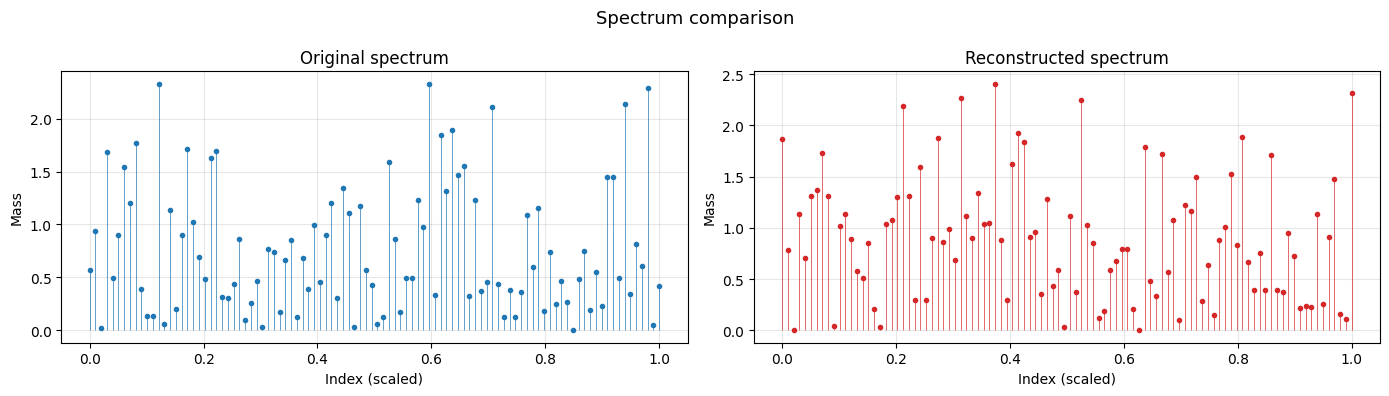

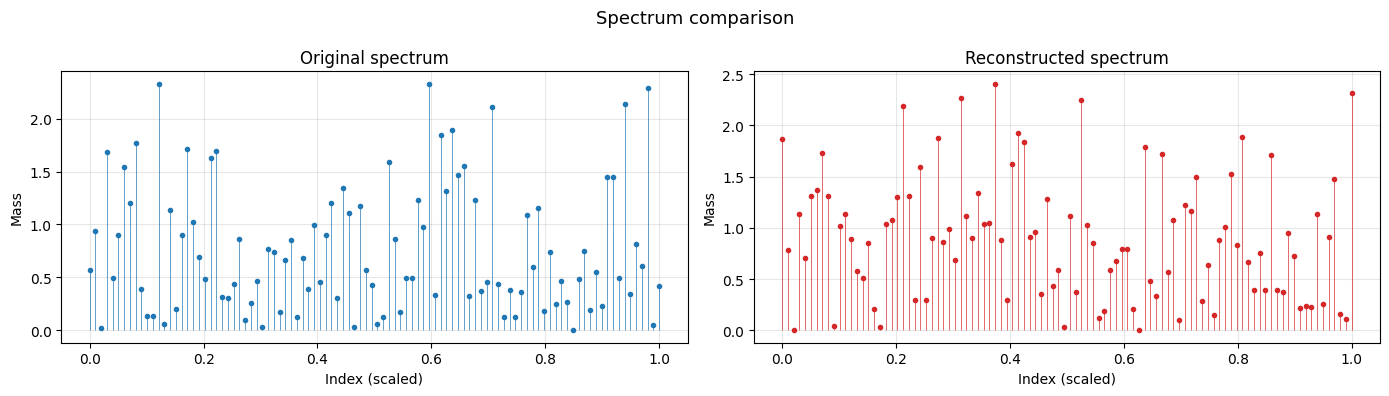

In [10]:
import numpy as np
import matplotlib.pyplot as plt

OG_COLOR = "#1f77b4"
RECON_COLOR = "#d62728"

def plot_two_vectors_separate(
    a,
    b,
    *,
    x_a=None,
    x_b=None,
    labels=("Vector A", "Vector B"),
    ylabel="Mass",
    title=None,
    figsize=(14,4),
):

    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()

    if x_a is None:
        x_a = np.linspace(0, 1, len(a))
    if x_b is None:
        x_b = np.linspace(0, 1, len(b))

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ── Left panel (stem style) ─────────────────────────────
    markerline_a, stemlines_a, baseline_a = axes[0].stem(
        x_a, a, basefmt=" "
    )
    markerline_a.set(color=OG_COLOR, markersize=3)
    stemlines_a.set(color=OG_COLOR, linewidth=0.7, alpha=0.7)

    axes[0].set(
        xlabel="Index (scaled)",
        ylabel=ylabel,
        title=labels[0],
    )
    axes[0].grid(True, alpha=0.3)

    # ── Right panel (same stem style) ───────────────────────
    markerline_b, stemlines_b, baseline_b = axes[1].stem(
        x_b, b, basefmt=" "
    )
    markerline_b.set(color=RECON_COLOR, markersize=3)
    stemlines_b.set(color=RECON_COLOR, linewidth=0.7, alpha=0.7)

    axes[1].set(
        xlabel="Index (scaled)",
        ylabel=ylabel,
        title=labels[1],
    )
    axes[1].grid(True, alpha=0.3)

    if title is not None:
        fig.suptitle(title, fontsize=13)

    plt.tight_layout()
    plt.show()

    return fig

a = np.abs(np.random.randn(100))
b = np.abs(np.random.randn(100))

plot_two_vectors_separate(
    a, b,
    labels=("Original spectrum", "Reconstructed spectrum"),
    title="Spectrum comparison"
)

/var/folders/zc/y9lfvlpn2b5g62zy54q0xfxc0000gn/T/ipykernel_41020/2148732904.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


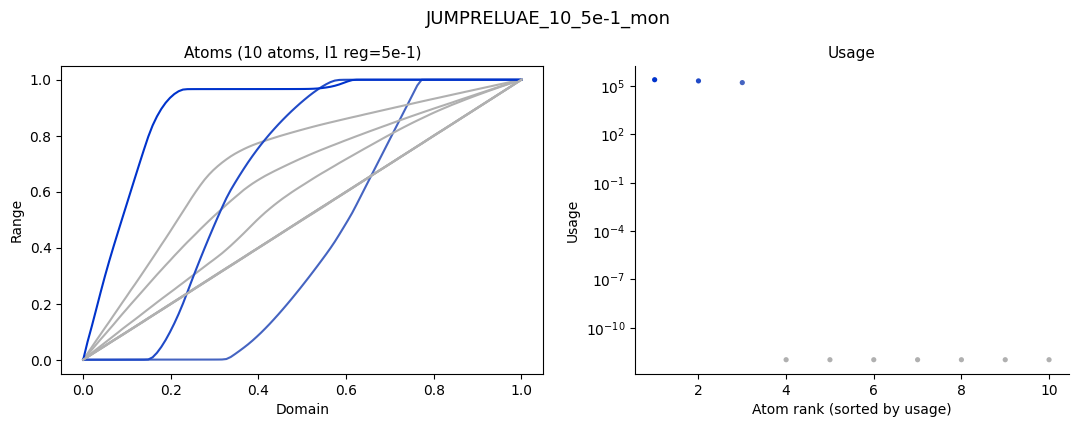

In [11]:
import numpy as np
from matplotlib.colors import to_rgb

def _usage_color_map(usage, low='#b0b0b0', high='#0033cc', gamma=1.2):
    usage = np.asarray(usage, dtype=float)

    # normalize to [0,1]
    umin = usage.min()
    umax = usage.max()
    if umax > umin:
        norm = (usage - umin) / (umax - umin)
    else:
        norm = np.zeros_like(usage)

    # optional contrast adjustment
    norm = norm ** gamma

    low_rgb = np.array(to_rgb(low))
    high_rgb = np.array(to_rgb(high))

    colors = [low_rgb * (1 - t) + high_rgb * t for t in norm]

    return colors, norm, (umin, umax)

def plot_atoms_overlay(key, indices=None, normalize=True, alpha=1,
                       codes_3d=None, usage=None,
                       low_color='#b0b0b0', high_color='#0033cc',
                       gamma=1.2,
                       add_usage_scatter=True, usage_scatter_logy=True,
                       point_size=14):

    """
    Left: overlay of atoms, colored by usage (gray -> intense blue).
    Right: usage dropoff scatter (rank vs usage), colored by the same atom colors.
    No colorbar.
    """

    cfg = SAE_PARAMETERS[key]
    model = load_model(cfg['architecture'], cfg['hidden_dim'], model_path_for(key),
                       top_k=cfg.get('top_K'))

    A = get_atoms(model)  # (k, m)
    k, m = A.shape
    x = np.linspace(0, 1, m)

    atom_indices = list(range(k)) if indices is None else [int(i) for i in indices]

    # --- compute / validate usage ---
    if usage is None:
        if codes_3d is None:
            raise ValueError("Provide either codes_3d (a,b,k) or usage (k,).")
        a, b, c = codes_3d.shape
        if c != k:
            raise ValueError(f"codes_3d last dim {c} does not match number of atoms k={k}.")
        flat_codes = codes_3d.reshape(a * b, c)
        usage = flat_codes.sum(dim=0)

    usage_np = usage.detach().cpu().numpy() if torch.is_tensor(usage) else np.asarray(usage, dtype=float)

    if usage_np.shape[0] != k:
        raise ValueError(f"usage has length {usage_np.shape[0]} but expected k={k}.")

    # --- global atom color mapping ---
    colors_all, _, _ = _usage_color_map(
        usage_np, low=low_color, high=high_color, gamma=gamma
    )

    # --- layout ---
    if add_usage_scatter:
        fig = plt.figure(figsize=(13, 4))
        gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 0.9], wspace=0.2)
        ax = fig.add_subplot(gs[0, 0])
        axu = fig.add_subplot(gs[0, 1])
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        axu = None

    # --- left plot ---
    for i in atom_indices:
        y = normalize_inv_cdf(A[i]) if normalize else A[i]
        ax.plot(x, y, alpha=1.0, color=colors_all[i], linewidth=1.5)

    ax.set(xlabel='Domain', ylabel='Range')
    ax.set_title(f'Atoms ({len(atom_indices)} atoms, l1 reg={cfg["l1"]})', fontsize=11)

    # --- right scatter ---
    if add_usage_scatter:

        idx_sorted = np.argsort(-usage_np)
        usage_sorted = usage_np[idx_sorted]
        ranks = np.arange(1, k + 1)

        point_colors = [colors_all[i] for i in idx_sorted]

        axu.scatter(
            ranks,
            np.maximum(usage_sorted, 1e-12),
            s=point_size,
            c=point_colors,
            linewidths=0
        )

        axu.set_title('Usage', fontsize=11)
        axu.set_xlabel('Atom rank (sorted by usage)')
        axu.set_ylabel('Usage')

        if usage_scatter_logy:
            axu.set_yscale('log')

        axu.spines['top'].set_visible(False)
        axu.spines['right'].set_visible(False)

    # --- figure-level title ---
    fig.suptitle(f"{key}", fontsize=13, y=1.02)

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    return fig

fig = plot_atoms_overlay(
    key=ANALYSIS_KEY,
    codes_3d=codes_3d)
plt.show()

## 5. Reconstructions

### Loading train and val splits

In [12]:
import torch
from pathlib import Path

def load_splits(data_dir,seed=0):
    """
    Load Pavia hyperspectral data and split into train/val sets.
    Uses the same seed as the original training script for identical split.
    
    Args:
        data_dir: path to .pt file containing data
        seed: Random seed (default: 0, same as training script)
    
    Returns:
        train_data: Training tensor
        val_data: Validation tensor
    """
    torch.manual_seed(seed)
    
    # Load the data
    data = torch.load(data_dir)
    if torch.is_tensor(data):
        cube = data
    elif isinstance(data, dict) and "cube" in data:
        cube = data["cube"]
    
    # Flatten the cube
    a, b, c = cube.shape
    flat_cube = cube.reshape(a * b, c)
    
    # Split into train/val (95% train, 5% val)
    n_samples = flat_cube.shape[0]
    n_val = int(0.05 * n_samples)
    
    perm = torch.randperm(n_samples)
    val_indices = perm[:n_val]
    train_indices = perm[n_val:]
    
    train_data = flat_cube[train_indices]
    val_data = flat_cube[val_indices]
    
    print(f"Train samples: {len(train_data)}, Val samples: {len(val_data)}")
    
    return train_data, val_data

# Usage:

ORIGINAL_PT    = DATA_DIR / 'data' / 'pavia_cube.pt'

train_data, val_data = load_splits(POTENTIAL_PT,seed=0)
og_cube_train,og_cube_val=load_splits(ORIGINAL_PT,seed=0)
# Reconstruct for all data
full_reconstruction_dict = {}
for key, cfg in SAE_PARAMETERS.items():
    print(f'Reconstructing {key} ...')
    model = load_model(cfg['architecture'], cfg['hidden_dim'], model_path_for(key),
                       top_k=cfg.get('top_K'))
    xhat, mse = synthesis_monotone(potential_cube, full_code_dict[key], model)
    full_reconstruction_dict[key] = {'recons': xhat, 'mse': mse}
    print(f'  → mean MSE = {mse.mean():.6f}')




Train samples: 744458, Val samples: 39182
Train samples: 744458, Val samples: 39182
Reconstructing JUMPRELUAE_10_1e-2_mon ...
  → mean MSE = 0.000102
Reconstructing JUMPRELUAE_10_5e-1_mon ...
  → mean MSE = 0.003667
Reconstructing JUMPRELUAE_10_1e-8_mon ...
  → mean MSE = 0.000047


In [13]:
# Encode all models
val_potential_code_dict = {}
for key, cfg in SAE_PARAMETERS.items():
    print(f'Encoding {key} ...')
    codes = sae_encode_potential_batch(
        val_data,
        model_path_for(key),
        cfg['architecture'],
        INPUT_DIM,
        cfg['hidden_dim'],
        cfg['top_K'],
        device=DEVICE,
        batch_size=1024,
    )
    val_potential_code_dict[key] = codes
    print(f'  → shape {codes.shape}')

Encoding JUMPRELUAE_10_1e-2_mon ...
  → shape torch.Size([39182, 10])
Encoding JUMPRELUAE_10_5e-1_mon ...
  → shape torch.Size([39182, 10])
Encoding JUMPRELUAE_10_1e-8_mon ...
  → shape torch.Size([39182, 10])


In [14]:
# Reconstruct for all data
full_reconstruction_dict = {}
for key, cfg in SAE_PARAMETERS.items():
    print(f'Reconstructing {key} ...')
    model = load_model(cfg['architecture'], cfg['hidden_dim'], model_path_for(key),
                       top_k=cfg.get('top_K'))
    xhat, mse = synthesis_monotone(potential_cube, full_code_dict[key], model)
    full_reconstruction_dict[key] = {'recons': xhat, 'mse': mse}
    print(f'  → mean MSE = {mse.mean():.6f}')


# Reconstruct for val data
val_reconstruction_dict = {}
for key, cfg in SAE_PARAMETERS.items():
    print(f'Reconstructing {key} ...')
    model = load_model(cfg['architecture'], cfg['hidden_dim'], model_path_for(key),
                       top_k=cfg.get('top_K'))
    xhat, mse = synthesis_monotone(val_data, val_potential_code_dict[key], model)

    val_reconstruction_dict[key] = {'recons': xhat, 'mse': mse}
    print(f'  → mean MSE (VAL) = {mse.mean():.6f}')

Reconstructing JUMPRELUAE_10_1e-2_mon ...
  → mean MSE = 0.000102
Reconstructing JUMPRELUAE_10_5e-1_mon ...
  → mean MSE = 0.003667
Reconstructing JUMPRELUAE_10_1e-8_mon ...
  → mean MSE = 0.000047
Reconstructing JUMPRELUAE_10_1e-2_mon ...
  → mean MSE (VAL) = 0.000107
Reconstructing JUMPRELUAE_10_5e-1_mon ...
  → mean MSE (VAL) = 0.003670
Reconstructing JUMPRELUAE_10_1e-8_mon ...
  → mean MSE (VAL) = 0.000049


In [15]:
# ── MSE summary across all models ──
print(f'{"Model":<35s}  {"Mean MSE":>12s}')
print('-' * 50)
for key in val_reconstruction_dict:
    m = val_reconstruction_dict[key]['mse'].mean().item()
    print(f'{key:<35s}  {m:12.6f}')


Model                                    Mean MSE
--------------------------------------------------
JUMPRELUAE_10_1e-2_mon                   0.000107
JUMPRELUAE_10_5e-1_mon                   0.003670
JUMPRELUAE_10_1e-8_mon                   0.000049


In [16]:
# ── MSE summary across all models ──
print(f'{"Model":<35s}  {"Mean MSE":>12s}')
print('-' * 50)
for key in val_reconstruction_dict:
    m = val_reconstruction_dict[key]['mse'].mean().item()
    print(f'{key:<35s}  {m:12.6f}')

Model                                    Mean MSE
--------------------------------------------------
JUMPRELUAE_10_1e-2_mon                   0.000107
JUMPRELUAE_10_5e-1_mon                   0.003670
JUMPRELUAE_10_1e-8_mon                   0.000049


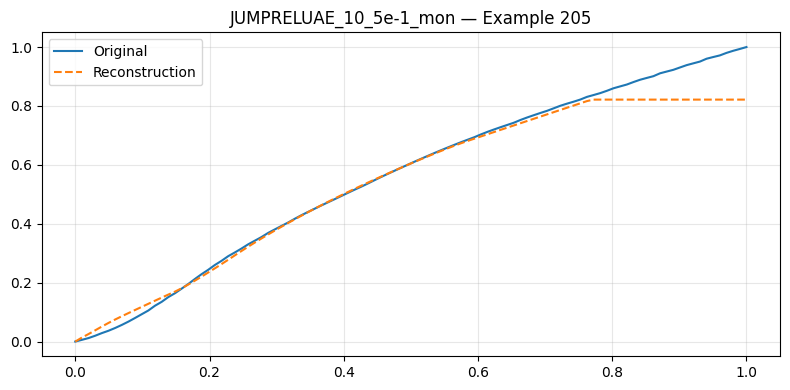

In [17]:
def plot_pixel_comparison(key, i, potential_cube, og_cube=None):
    """Compare original potential and reconstruction for a single pixel."""
    recon = val_reconstruction_dict[key]['recons'][i]
    orig  = val_data[i]
    x = np.linspace(0, 1, len(orig))

    plt.figure(figsize=(8, 4))
    plt.plot(x, orig.numpy() if torch.is_tensor(orig) else orig, label='Original')
    plt.plot(x, recon.numpy() if torch.is_tensor(recon) else recon, label='Reconstruction', ls='--')

   # if og_cube is not None:
     #   spec = og_cube[i, j] if not isinstance(og_cube, dict) else og_cube
      #  spec = np.asarray(spec, dtype=np.float64)
      #  spec_norm = spec / (spec.sum() + 1e-12)
       # plt.plot(np.linspace(0, 1, len(spec_norm)), spec_norm,
              #   label='Original spectrum (normalized)', alpha=0.7)

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'{key} — Example {i}')
    plt.tight_layout()
    plt.show()
    


# Example
plot_pixel_comparison(ANALYSIS_KEY, 205, potential_cube, og_cube)

In [18]:
# ── Brenier / Wasserstein helper (if needed) ──

def process_single_pixel(i, j, cube, source_supp_size):
    """Compute Wasserstein map for a single pixel."""
    target_grid = np.linspace(0.0, 1.0, cube.shape[2])
    source_grid = np.linspace(0.0, 1.0, source_supp_size)
    target_masses = cube[i, j, :].reshape(-1)
    result = wass_map_1D(source_grid, None, target_grid, target_masses)
    return result.cpu().numpy() if torch.is_tensor(result) else np.array(result)


In [19]:
'''
def plot_pixel_comparison(key, i, j, potential_cube, og_cube=None, method='fd',
                          bandwidth=0.05, n_samples=20000):
    """Compare original and reconstructed pixel.

    Panel 1: Original vs reconstructed inverse-CDF.
    Panel 2: Reconstructed density (normalized so values sum to 1)
             + og_cube spectrum. Each on its own grid.
    """
    orig  = potential_cube[i, j]
    recon = reconstruction_dict[key]['recons'][i, j]
    orig_np  = orig.numpy()  if torch.is_tensor(orig)  else np.asarray(orig,  dtype=np.float64)
    recon_np = recon.numpy() if torch.is_tensor(recon) else np.asarray(recon, dtype=np.float64)

    orig_T  = normalize_inv_cdf(orig_np)
    recon_T = normalize_inv_cdf(recon_np)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ── Panel 1: inverse-CDFs ──
    p = np.linspace(0, 1, len(orig_T))
    axes[0].plot(p, orig_T,  label='OT Map Embedding', lw=1.2)
    axes[0].plot(p, recon_T, label='Reconstruction',   lw=1.2, ls='--')
    axes[0].set(xlabel='Quantile $p$', ylabel='$T(p)$', title='Transport map')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Panel 2: densities on their own grids ──
    if method in ('fd', 'both'):
        y_fd, pdf_fd = fd_density_from_inv_cdf(recon_T)
        pdf_fd = pdf_fd / (pdf_fd.sum() + 1e-12)

        print('recon_sum',pdf_fd.sum())
        print('recon_supp_size',len(pdf_fd))
        axes[1].plot(y_fd, pdf_fd, color='C1', ls='--', lw=1.0,
                     alpha=0.9, label='Reconstructed (FD)')

    if method in ('kde', 'both'):
        _, x_kde, pdf_kde = kde_density_from_inv_cdf(
            recon_T, n_samples=n_samples, bandwidth=bandwidth)
        pdf_kde = pdf_kde / (pdf_kde.sum() + 1e-12)

        print('recon_sum',pdf_kde.sum())
        print('recon_supp_size',len(pdf_kde))
        axes[1].plot(x_kde, pdf_kde, color='C1', ls=':', lw=1.0,
                     alpha=0.9, label='Reconstructed (KDE)')

    if og_cube is not None:
        spec = og_cube[i, j]
        spec = spec.numpy() if torch.is_tensor(spec) else np.asarray(spec, dtype=np.float64)
        axes[1].plot(np.linspace(0, 1, len(spec)), spec, color='C2',
                     lw=1.2, alpha=0.8, label='Original hyperspectrum')
        print('spec_sum',spec.sum())
        print('spec_supp_size',len(spec))
    axes[1].set(xlabel='$y$', ylabel='Density', title='Spectra comparison')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f'{key} — pixel ({i},{j})', fontsize=13)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

plot_pixel_comparison(ANALYSIS_KEY, 100, 100, potential_cube, og_cube=og_cube, method='fd')
'''

'\ndef plot_pixel_comparison(key, i, j, potential_cube, og_cube=None, method=\'fd\',\n                          bandwidth=0.05, n_samples=20000):\n    """Compare original and reconstructed pixel.\n\n    Panel 1: Original vs reconstructed inverse-CDF.\n    Panel 2: Reconstructed density (normalized so values sum to 1)\n             + og_cube spectrum. Each on its own grid.\n    """\n    orig  = potential_cube[i, j]\n    recon = reconstruction_dict[key][\'recons\'][i, j]\n    orig_np  = orig.numpy()  if torch.is_tensor(orig)  else np.asarray(orig,  dtype=np.float64)\n    recon_np = recon.numpy() if torch.is_tensor(recon) else np.asarray(recon, dtype=np.float64)\n\n    orig_T  = normalize_inv_cdf(orig_np)\n    recon_T = normalize_inv_cdf(recon_np)\n\n    fig, axes = plt.subplots(1, 2, figsize=(14, 4))\n\n    # ── Panel 1: inverse-CDFs ──\n    p = np.linspace(0, 1, len(orig_T))\n    axes[0].plot(p, orig_T,  label=\'OT Map Embedding\', lw=1.2)\n    axes[0].plot(p, recon_T, label=\'Reconstru

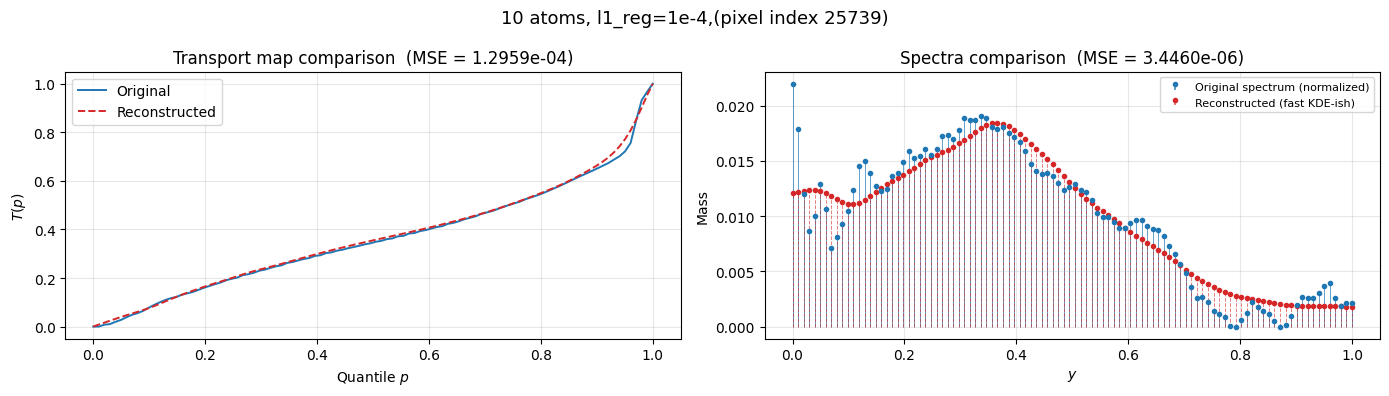

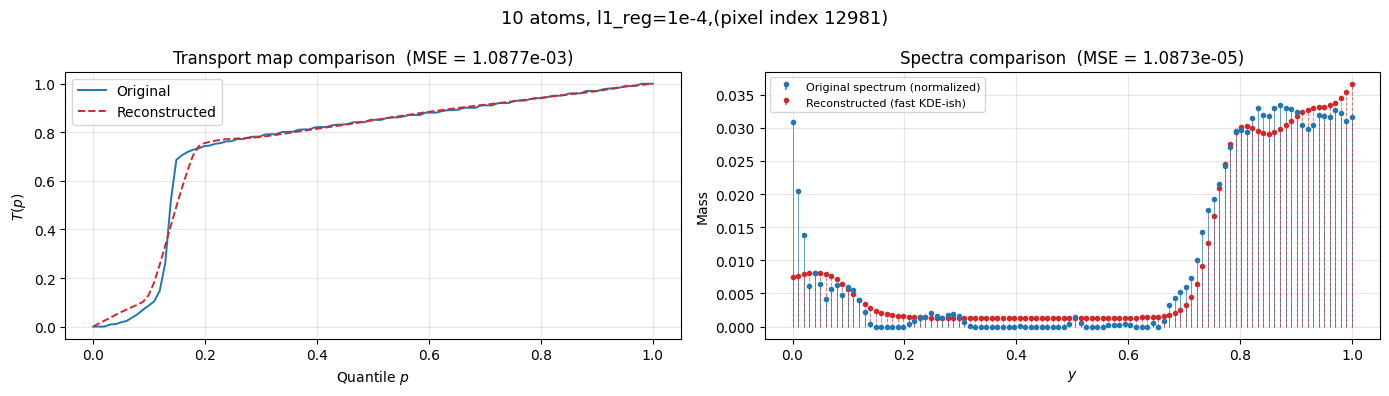

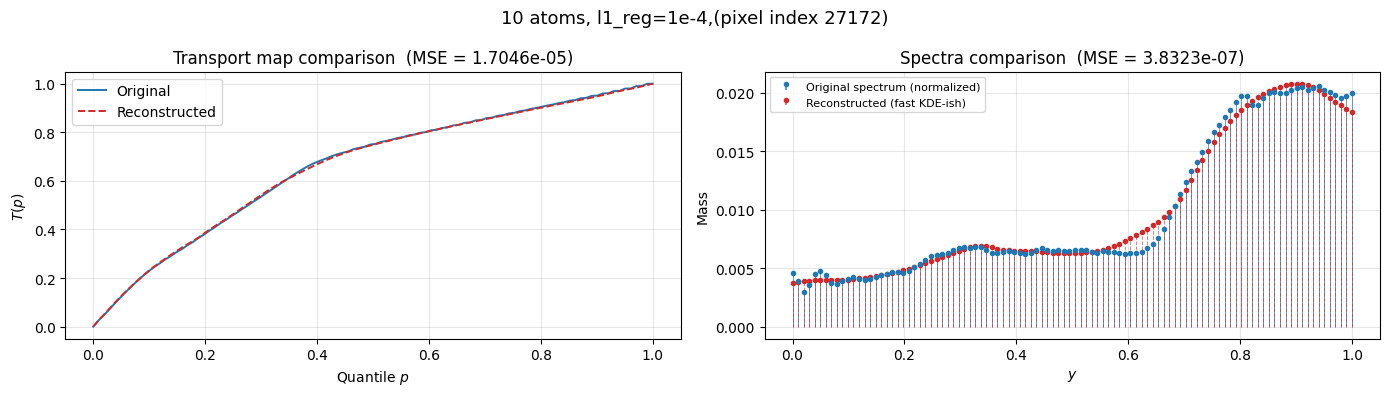

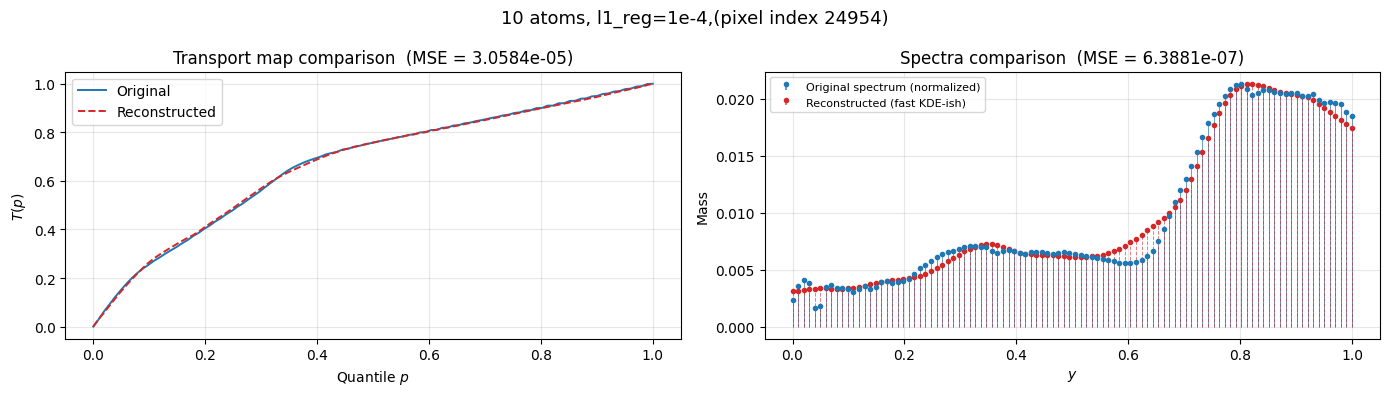

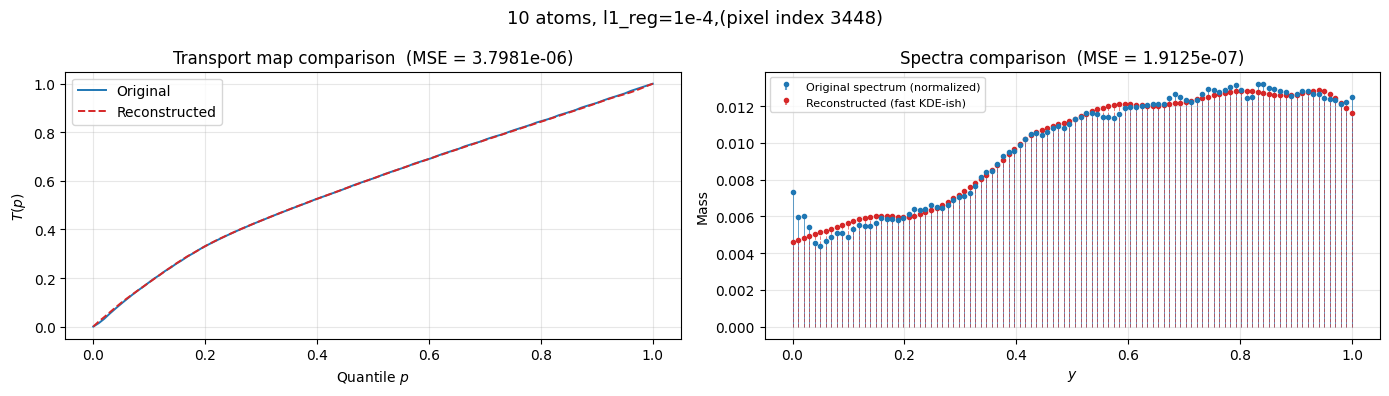

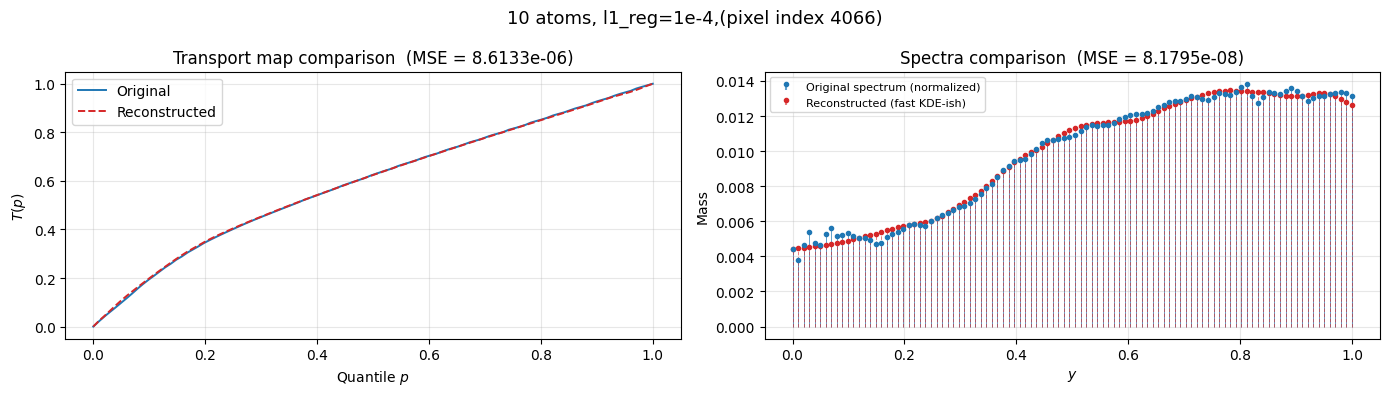

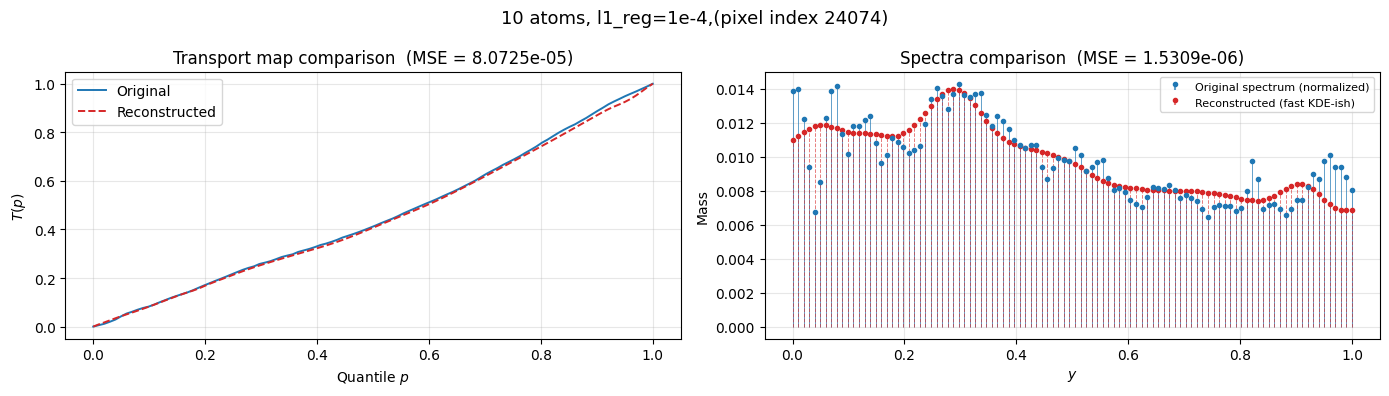

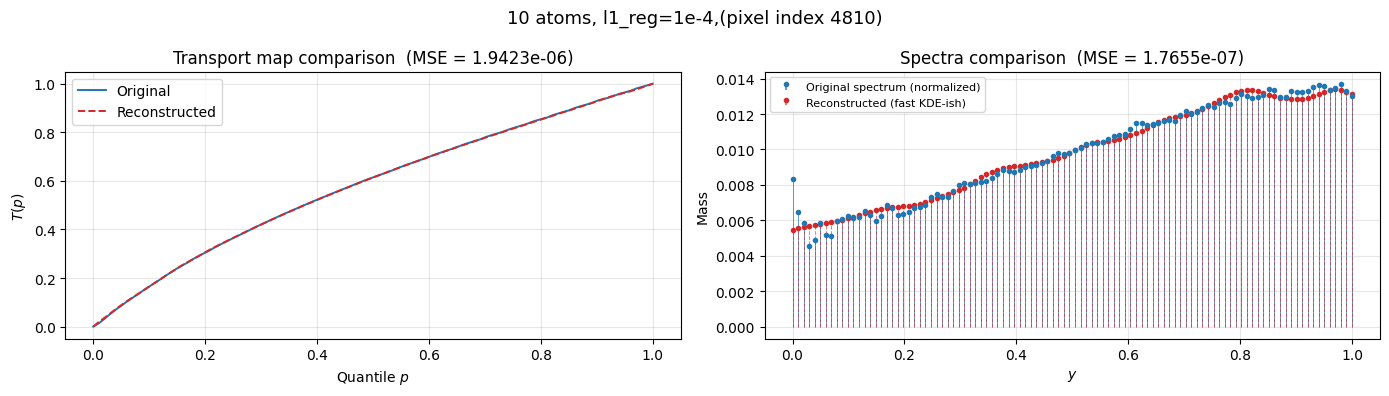

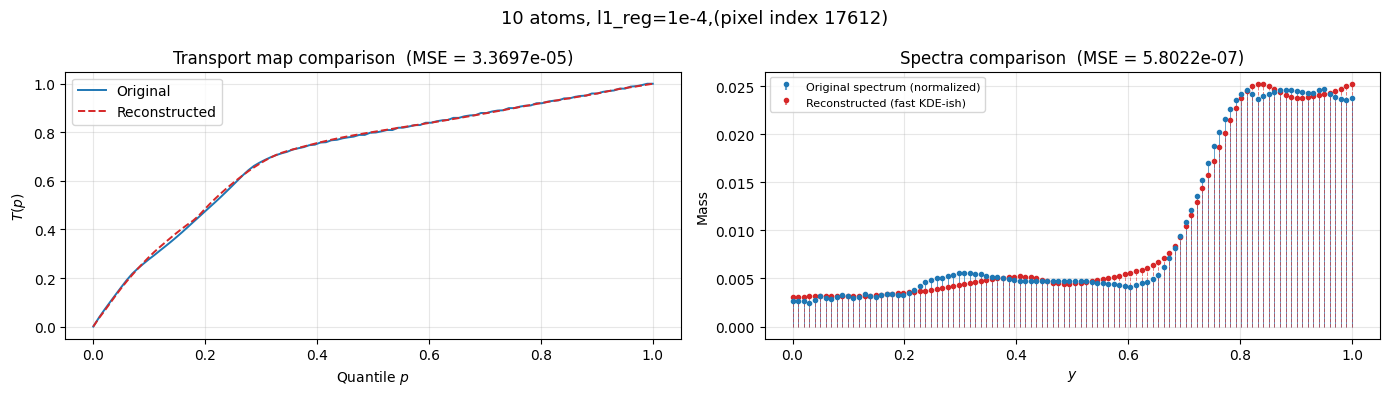

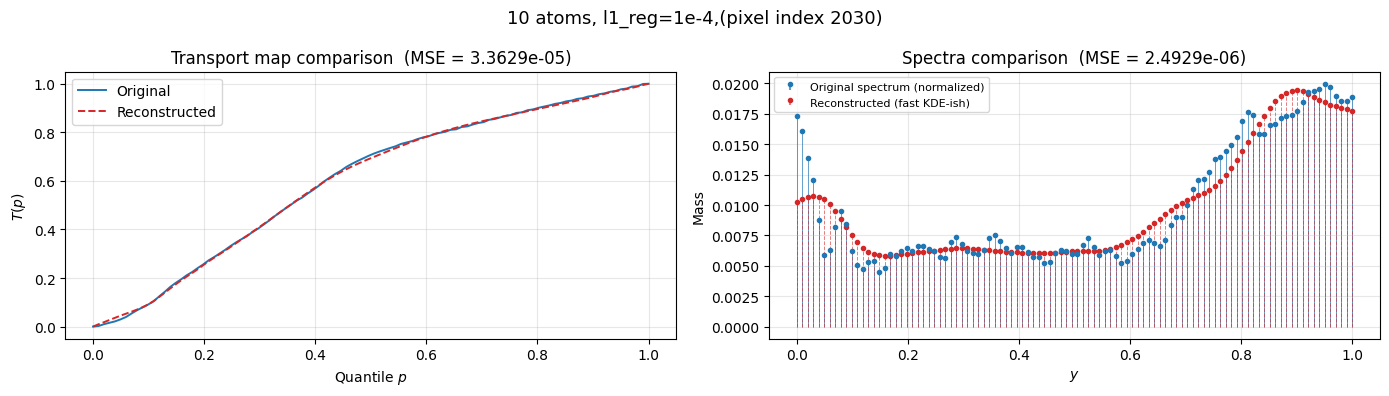

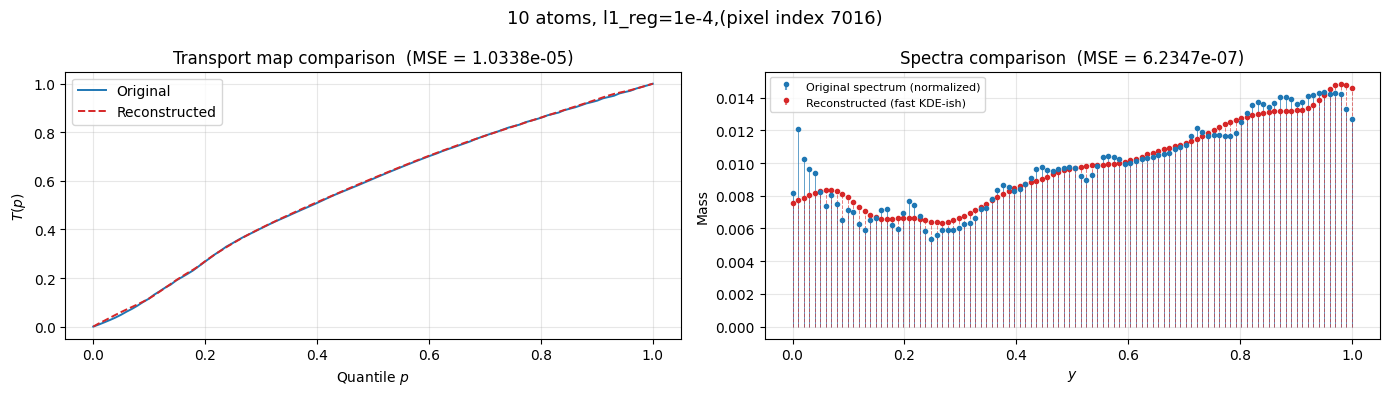

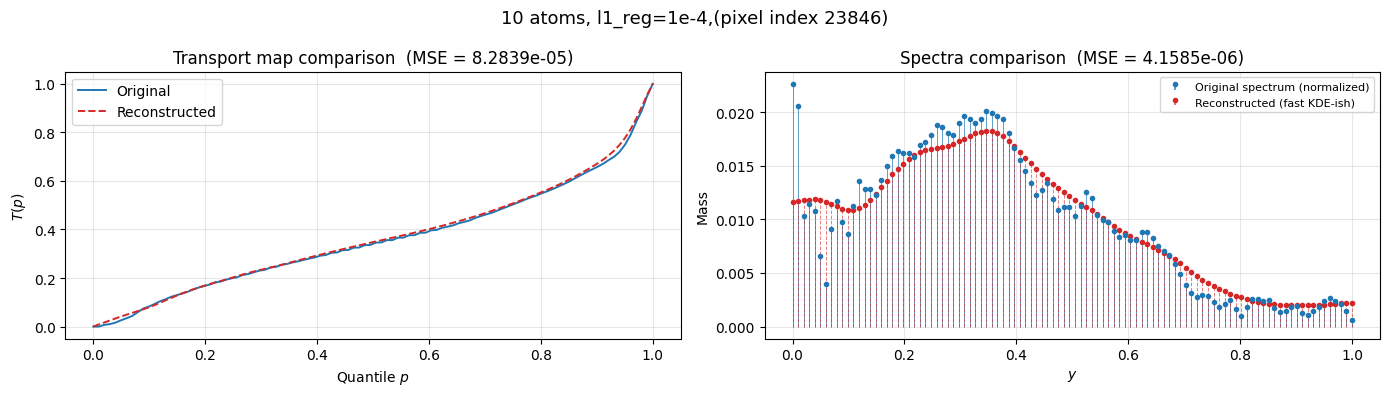

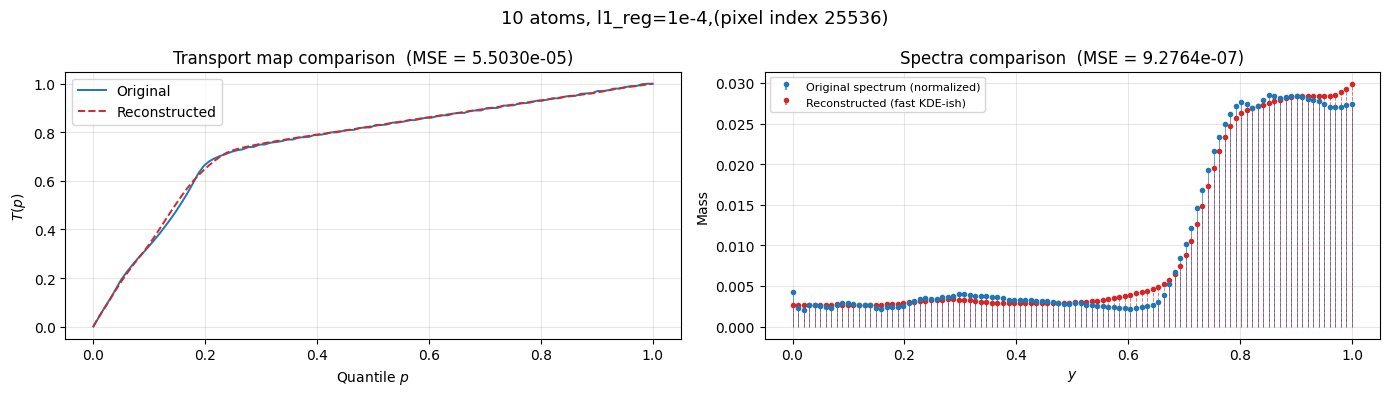

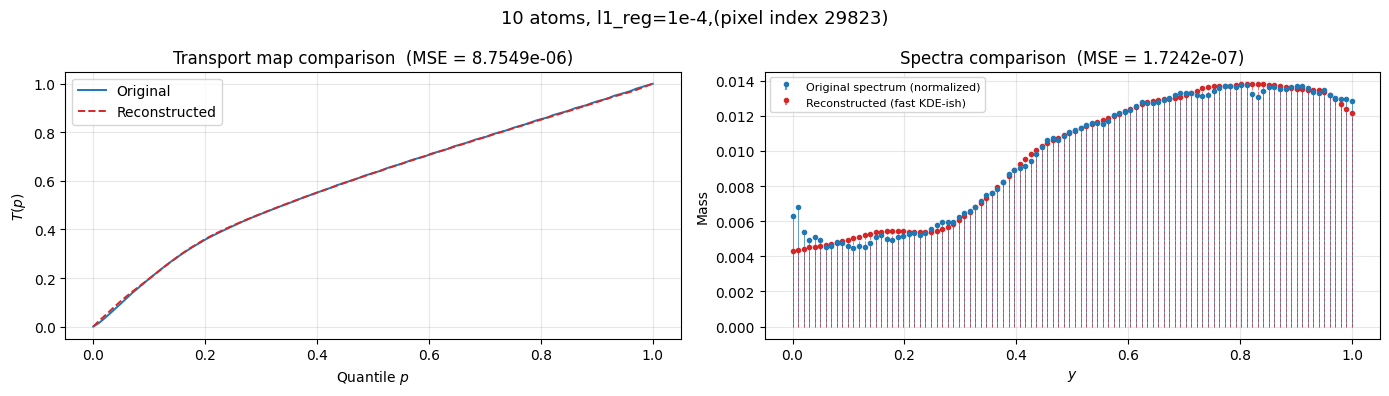

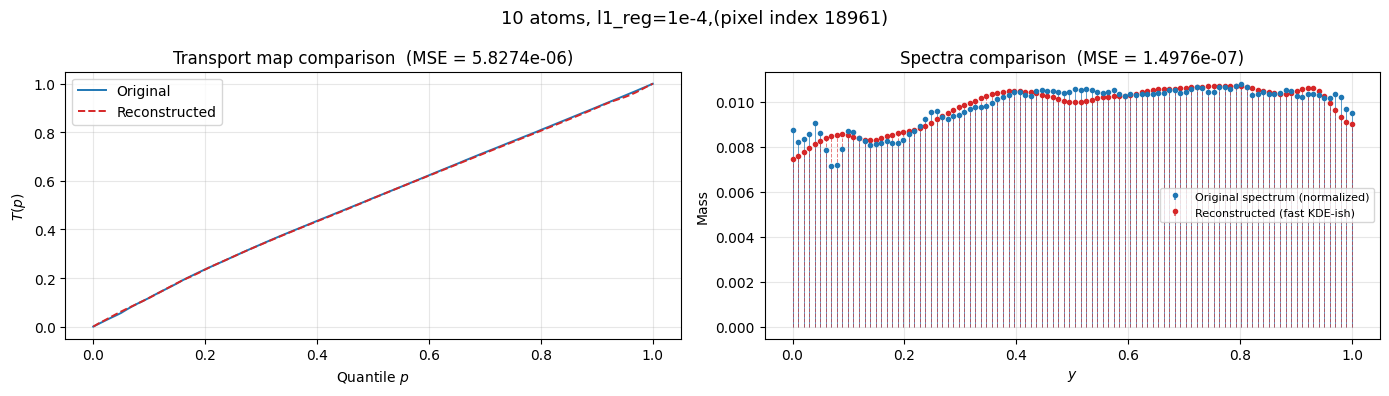

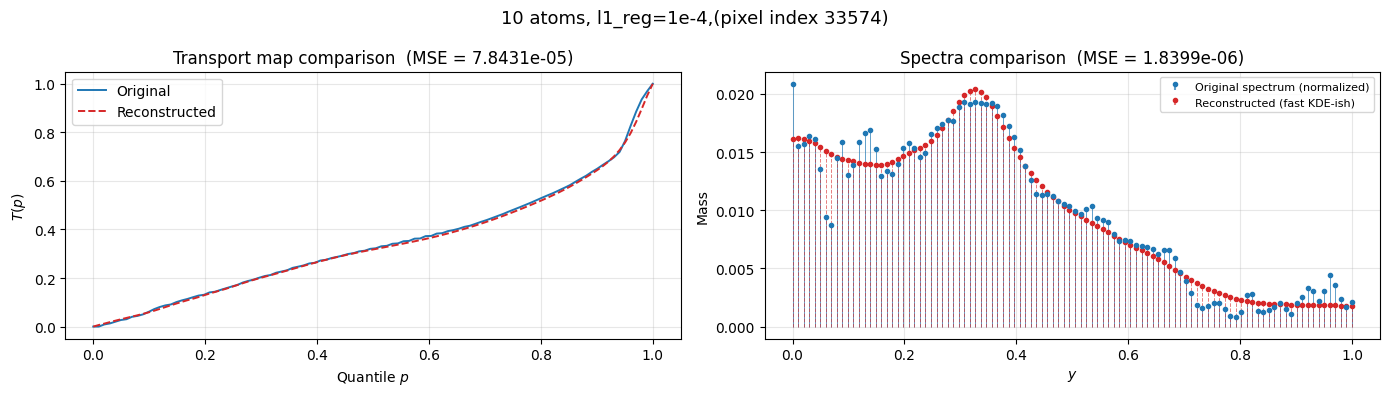

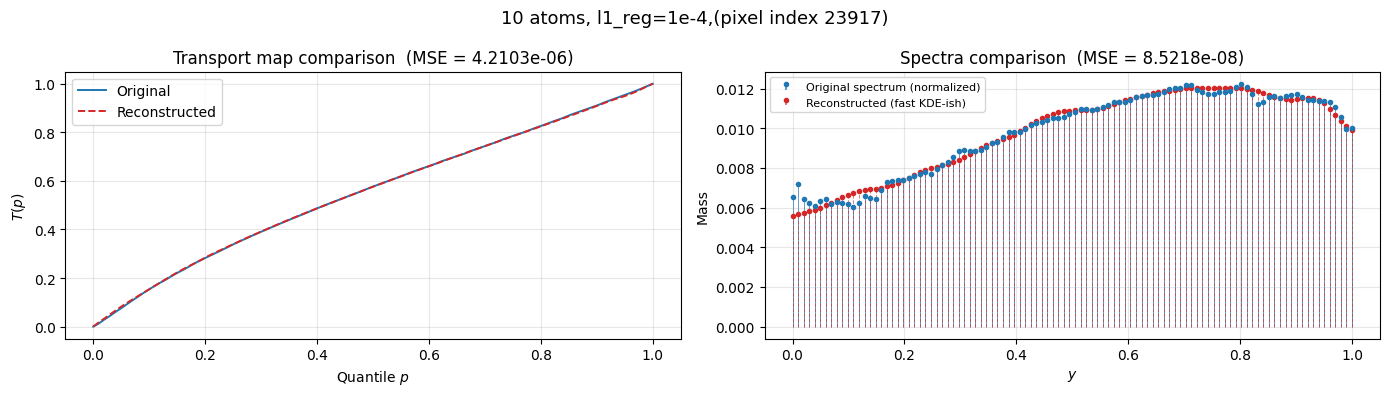

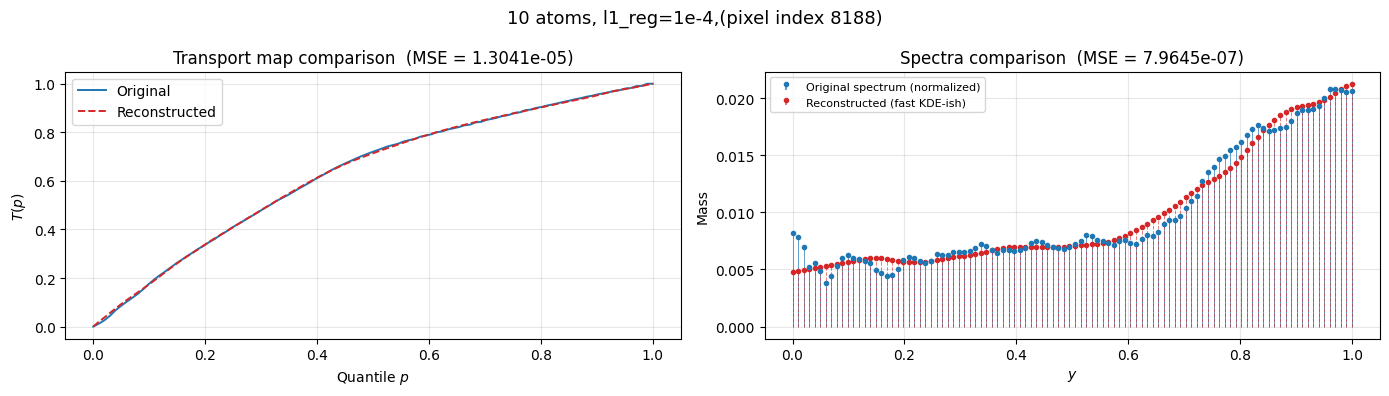

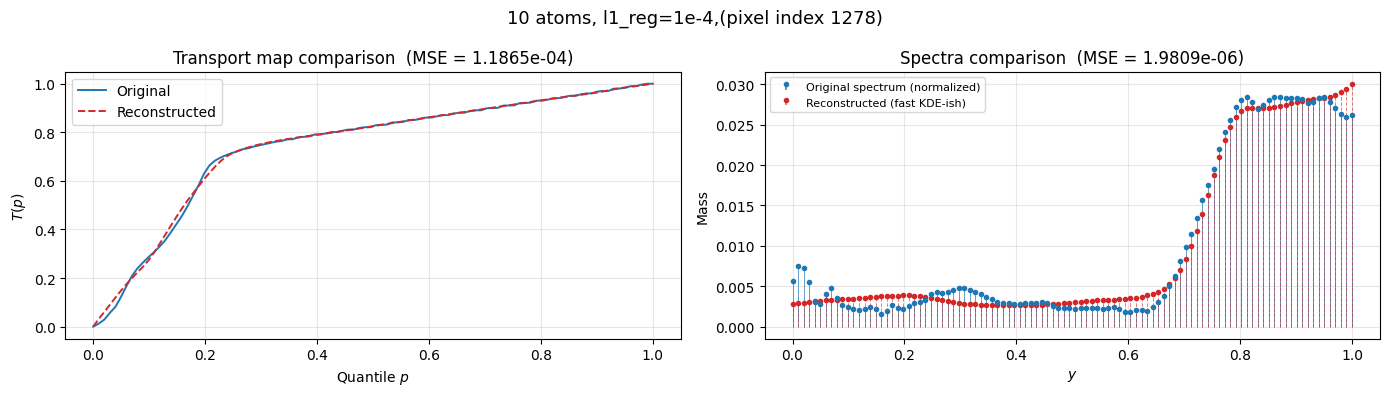

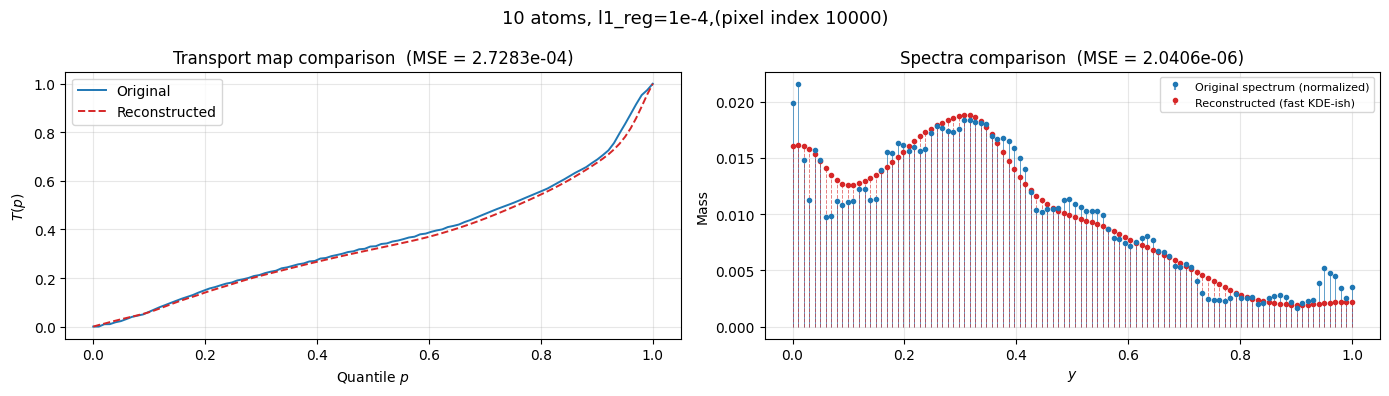

In [20]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


# -----------------------------
# Helpers
# -----------------------------
def normalize_inv_cdf(inv_cdf: np.ndarray) -> np.ndarray:
    """Enforce monotonicity and normalize inverse-CDF values to [0, 1]."""
    x = np.asarray(inv_cdf, dtype=np.float64)
    x = np.maximum.accumulate(x)
    lo, hi = x.min(), x.max()
    if hi - lo < 1e-12:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)

def fast_spectrum_from_inv_cdf(inv_cdf, D, *, n_samples=20000, sigma_bins=1.5, x_grid=None):
    inv_cdf = np.asarray(inv_cdf, dtype=np.float64)

    p_grid = np.linspace(0.0, 1.0, inv_cdf.size)
    u = np.random.rand(n_samples)
    samples = np.interp(u, p_grid, inv_cdf)

    if x_grid is None:
        x_grid = np.linspace(inv_cdf.min(), inv_cdf.max(), D)

    edges = np.linspace(x_grid[0], x_grid[-1], D + 1)
    counts, _ = np.histogram(samples, bins=edges, density=False)

    dx = edges[1] - edges[0]
    density = counts.astype(np.float64) / (n_samples * dx)

    density = gaussian_filter1d(density, sigma=sigma_bins, mode="nearest")
    density /= np.trapz(density, x_grid)
    return x_grid, density



def _to_numpy(x):
    """Convert tensor or array-like to float64 numpy array."""
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().astype(np.float64)
    return np.asarray(x, dtype=np.float64)


# -----------------------------
# Plot function
# -----------------------------

# Distinct style constants
OG_COLOR = "#1f77b4"       # blue
RECON_COLOR = "#d62728"    # red
def plot_pixel_comparison_fast(
    key,
    idx,
    potential_data,
    dictionary,
    og_data=None,
    *,
    bandwidth=0.03,          # interpreted in x-units
    n_samples=50000,
    title=None,
    out_dir="hyperspec_images/reconstruction_examples",
):
    """
    Compare original and reconstructed pixel.

    Panel 1: Original vs reconstructed inverse-CDF.
    Panel 2: Original spectrum vs reconstructed density (stem plots with distinct colours).

    This version uses:
        inverse-CDF sampling -> histogram -> gaussian smoothing
    via fast_spectrum_from_inv_cdf, with bandwidth converted to sigma_bins.
    """
    os.makedirs(out_dir, exist_ok=True)

    orig_np = _to_numpy(potential_data[idx])
    recon_np = _to_numpy(dictionary[key]["recons"][idx])

    orig_T = normalize_inv_cdf(orig_np)
    recon_T = normalize_inv_cdf(recon_np)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ── Panel 1: inverse-CDFs ──────────────────────────────────────────
    icdf_mse = np.mean((orig_T - recon_T) ** 2)
    p = np.linspace(0, 1, len(orig_T))

    axes[0].plot(p, orig_T, color=OG_COLOR, lw=1.4, label="Original")
    axes[0].plot(p, recon_T, color=RECON_COLOR, lw=1.4, ls="--", label="Reconstructed")
    axes[0].set(
        xlabel="Quantile $p$",
        ylabel="$T(p)$",
        title=f"Transport map comparison  (MSE = {icdf_mse:.4e})",
    )
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Panel 2: spectra stem plot ─────────────────────────────────────
    if og_data is not None:
        spec = _to_numpy(og_data[idx])
        spec = np.clip(spec, 0, None)
        spec = spec / (spec.sum() + 1e-12)
        x_grid = np.linspace(0, 1, len(spec))
    else:
        spec = None
        x_grid = np.linspace(0, 1, len(recon_T))

    # --- convert bandwidth (x-units) -> sigma_bins (bin-units) ---
    # assumes uniform x_grid
    if len(x_grid) >= 2:
        dx = float(x_grid[1] - x_grid[0])
    else:
        dx = 1.0
    sigma_bins = max(bandwidth / max(dx, 1e-12), 0.0)

    # --- fast spectrum (your sigma_bins version) ---
    x_den, den = fast_spectrum_from_inv_cdf(
        recon_T,
        D=len(x_grid),
        n_samples=n_samples,
        sigma_bins=sigma_bins,
        x_grid=x_grid,
    )

    # PMF-style normalization (sum to 1) like your old code
    den_pmf = den / (den.sum() + 1e-12)

    # -- Original spectrum stem (blue, solid) --
    pdf_mse_str = ""
    if spec is not None:
        markerline_og, stemlines_og, baseline_og = axes[1].stem(
            x_grid, spec, basefmt=" ", label="Original spectrum (normalized)",
        )
        markerline_og.set(color=OG_COLOR, markersize=3, zorder=3)
        stemlines_og.set(color=OG_COLOR, linewidth=0.7, alpha=0.7)

        # grids match already
        pdf_mse = np.mean((spec - den_pmf) ** 2)
        pdf_mse_str = f"  (MSE = {pdf_mse:.4e})"

    # -- Reconstructed density stem (red, dashed) --
    markerline_rc, stemlines_rc, baseline_rc = axes[1].stem(
        x_den, den_pmf, basefmt=" ", label="Reconstructed (fast KDE-ish)",
    )
    markerline_rc.set(color=RECON_COLOR, markersize=3, zorder=2)
    stemlines_rc.set(color=RECON_COLOR, linewidth=0.7, alpha=0.6, linestyle="--")

    axes[1].set(xlabel="$y$", ylabel="Mass", title=f"Spectra comparison{pdf_mse_str}")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # ── Title & save ───────────────────────────────────────────────────
    if title is None:
        fig.suptitle(f"{key} — pixel index {idx}", fontsize=13)
        filename = f"{key}_idx_{idx}.png"
    else:
        fig.suptitle(title, fontsize=13)
        filename = "".join(
            c if c.isalnum() or c in " .,_-()" else "_" for c in title
        ) + ".png"

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, filename), dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)



# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    ANALYSIS_KEY = "JUMPRELUAE_10_1e-8_mon"

    N = val_data.shape[0]
    idxs = np.random.choice(N, size=20, replace=False)

    for i in idxs:
        plot_pixel_comparison_fast(
            ANALYSIS_KEY, i, val_data, val_reconstruction_dict,
            og_data=og_cube_val,
            title=f"10 atoms, l1_reg=1e-4,(pixel index {i})",
        )

In [ ]:
def tune_density_hparams(
    potential_data,
    dictionary,
    og_data,
    key,
    *,
    bandwidth_grid=(0.005, 0.01, 0.02, 0.05),
    n_samples_grid=(2000, 5000, 20000),
    idxs=None,
):
    """
    Grid search for bandwidth + n_samples using MSE against OG spectra.

    Prints ALL trials sorted best → worst at the end.
    Returns sorted results list.
    """

    if idxs is None:
        N = potential_data.shape[0]
        idxs = np.arange(N)

    results = []

    print("\nStarting hyperparameter search\n")

    for bandwidth in bandwidth_grid:
        for n_samples in n_samples_grid:

            mses = []

            print(f"\nTesting bandwidth={bandwidth}, n_samples={n_samples}")

            for k, idx in enumerate(idxs):

                if k % 200 == 0:
                    print(f"  progress {k}/{len(idxs)}")

                recon_np = _to_numpy(dictionary[key]["recons"][idx])
                spec = _to_numpy(og_data[idx])
                spec = np.clip(spec, 0, None)
                spec = spec / (spec.sum() + 1e-12)
                recon_T = normalize_inv_cdf(recon_np)

                x_grid = np.linspace(0, 1, len(spec))

                # bandwidth → sigma_bins
                if len(x_grid) >= 2:
                    dx = float(x_grid[1] - x_grid[0])
                else:
                    dx = 1.0
                sigma_bins = max(bandwidth / max(dx, 1e-12), 0.0)

                x_den, den = fast_spectrum_from_inv_cdf(
                    recon_T,
                    D=len(x_grid),
                    n_samples=n_samples,
                    sigma_bins=sigma_bins,
                    x_grid=x_grid,
                )

                den_pmf = den / (den.sum() + 1e-12)
                mse = np.mean((spec - den_pmf) ** 2)
                mses.append(mse)

            mean_mse = float(np.mean(mses))
            print(f"  >>> mean MSE = {mean_mse:.6e}")

            results.append({
                "bandwidth": bandwidth,
                "n_samples": n_samples,
                "sigma_bins": sigma_bins,
                "mean_mse": mean_mse,
            })

    # -----------------------------
    # Sort results best → worst
    # -----------------------------
    results = sorted(results, key=lambda x: x["mean_mse"])

    print("\n" + "="*60)
    print("ALL TRIALS (best → worst)")
    print("="*60)

    for i, r in enumerate(results):
        print(
            f"{i+1:>3d}. "
            f"MSE={r['mean_mse']:.6e}   "
            f"bandwidth={r['bandwidth']:<8g}   "
            f"sigma_bins={r['sigma_bins']:<8.3f}   "
            f"n_samples={r['n_samples']}"
        )

    print("\nBEST CONFIG:")
    print(results[0])

    return results

idxs = np.random.choice(val_data.shape[0], size=2000, replace=False)

results = tune_density_hparams(
    val_data,
    val_reconstruction_dict,
    og_cube_val,
    key="JUMPRELUAE_10_5e-1_mon",
    bandwidth_grid=[ 0.03],
    n_samples_grid=[100000,200000],
    idxs=idxs,
)



Starting hyperparameter search


Testing bandwidth=0.03, n_samples=100000
  progress 0/2000
  progress 200/2000
  progress 400/2000
  progress 600/2000
  progress 800/2000
  progress 1000/2000
  progress 1200/2000
  progress 1400/2000
  progress 1600/2000
  progress 1800/2000
  >>> mean MSE = 3.076871e-04

Testing bandwidth=0.03, n_samples=200000
  progress 0/2000
  progress 200/2000
  progress 400/2000
  progress 600/2000
  progress 800/2000


## 6. Unsupervised Clustering Evaluation

### These cells assume full_corruption_sweep_hyperspec.sh has been run

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv(SWEEP_CSVS['drop_random'])

# 2. Define the columns we want to analyze (Mapping your CSV headers)
# Note: Adjust these strings if your CSV headers have slightly different spacing
baseline_col = 'k=None_mean'
noise_cols = ['k=0.1_mean', 'k=0.3_mean', 'k=0.4_mean', 'k=0.5_mean']
all_val_cols = [baseline_col] + noise_cols

# 3. Filter for a subset of rows (Example: Just Pavia or specific Keys)
# You can change this filter to target specific datasets or types
subset = df[df['dataset'] == 'botswana'].copy()

# 4. Calculate the Absolute Difference (Drop from Baseline)
# We subtract the noise value from the baseline. 
# A result of 0 means no change. A positive result means a performance drop.
for col in noise_cols:
    subset[f'diff_{col}'] = subset[baseline_col] - subset[col]

# 5. Reshape data for plotting
# We want: Method Name, Noise Level, Drop Value
plot_data = []
x_labels = [0.0, 0.1, 0.3, 0.4, 0.5]

for index, row in subset.iterrows():
    method_label = f"{row['type']} ({row['key']})"
    # Baseline difference is always 0
    diffs = [0] + [row[f'diff_{col}'] for col in noise_cols]
    
    for x, diff in zip(x_labels, diffs):
        plot_data.append({
            'Method': method_label,
            'Noise Level (k)': x,
            'Performance Drop': diff
        })

plot_df = pd.DataFrame(plot_data)

# 6. Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df, x='Noise Level (k)', y='Performance Drop', hue='Method', marker='o')

plt.title(f"Performance Degradation Analysis: {subset['dataset'].iloc[0]}", fontsize=14)
plt.ylabel("Absolute Drop from Baseline (k=0)", fontsize=12)
plt.xlabel("Noise Level (k)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv(SWEEP_CSVS['drop_contiguous'])

# 2. Define the columns (Matching your CSV headers)
baseline_col = 'k=None_mean'
noise_cols = ['k=0.1_mean', 'k=0.3_mean', 'k=0.4_mean', 'k=0.5_mean']
all_val_cols = [baseline_col] + noise_cols
x_values = [0.0, 0.1, 0.3, 0.4, 0.5]

# 3. Choose your subset (e.g., 'Pavia' or 'salinas_a')
target_dataset = 'Pavia'
subset = df[df['dataset'] == target_dataset].copy()

# 4. Reshape for Seaborn (Long Format)
plot_rows = []
for _, row in subset.iterrows():
    # Use key or a combination for the label
    label = f"{row['type']}: {row['key']}"
    
    for x, col in zip(x_values, all_val_cols):
        plot_rows.append({
            'Method': label,
            'Noise Level (k)': x,
            'Accuracy (Mean)': row[col],
            'Type': row['type']
        })

plot_df = pd.DataFrame(plot_rows)

# 5. Visualization
plt.figure(figsize=(11, 7))
# Using 'hue' for specific keys and 'style' for the architecture type
sns.lineplot(
    data=plot_df, 
    x='Noise Level (k)', 
    y='Accuracy (Mean)', 
    hue='Method', 
    style='Type', 
    markers=True, 
    markersize=8,
    linewidth=2
)

plt.title(f"Synthesis of Accuracy & Stability: {target_dataset}", fontsize=15, pad=20)
plt.ylabel("Performance (Mean Metric)", fontsize=12)
plt.xlabel("Increasing Contiguous Noise ($k$)", fontsize=12)
plt.ylim(0, 1.0) # Keeps the scale consistent for comparison
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv(SWEEP_CSVS['drop_random'])

# 2. Define the columns (Matching your CSV headers)
baseline_col = 'k=None_mean'
noise_cols = ['k=0.1_mean', 'k=0.3_mean', 'k=0.4_mean', 'k=0.5_mean']
all_val_cols = [baseline_col] + noise_cols
x_values = [0.0, 0.1, 0.3, 0.4, 0.5]

# 3. Choose your subset (e.g., 'Pavia' or 'salinas_a')
target_dataset = 'Pavia'
subset = df[df['dataset'] == target_dataset].copy()

# 4. Reshape for Seaborn (Long Format)
plot_rows = []
for _, row in subset.iterrows():
    # Use key or a combination for the label
    label = f"{row['type']}: {row['key']}"
    
    for x, col in zip(x_values, all_val_cols):
        plot_rows.append({
            'Method': label,
            'Noise Level (k)': x,
            'Accuracy (Mean)': row[col],
            'Type': row['type']
        })

plot_df = pd.DataFrame(plot_rows)

# 5. Visualization
plt.figure(figsize=(11, 7))
# Using 'hue' for specific keys and 'style' for the architecture type
sns.lineplot(
    data=plot_df, 
    x='Noise Level (k)', 
    y='Accuracy (Mean)', 
    hue='Method', 
    style='Type', 
    markers=True, 
    markersize=8,
    linewidth=2
)

plt.title(f"Synthesis of Accuracy & Stability: {target_dataset}", fontsize=15, pad=20)
plt.ylabel("Performance (Mean Metric)", fontsize=12)
plt.xlabel("Increasing Contiguous Noise ($k$)", fontsize=12)
plt.ylim(0, 1.0) # Keeps the scale consistent for comparison
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# 1. Load the data
df = pd.read_csv(SWEEP_CSVS['log_warp'])

# 2. Define columns and noise levels
baseline_col = 'k=None_mean'
noise_cols = ['k=0.1_mean', 'k=0.3_mean', 'k=0.4_mean', 'k=0.5_mean']
all_val_cols = [baseline_col] + noise_cols
x_values = [0.0, 0.1, 0.3, 0.4, 0.5]

# 3. Calculate robustness score (average accuracy) for ranking the best reps
df['robustness_score'] = df[all_val_cols].mean(axis=1)

# 4. Prepare the figure - increased bottom margin slightly for legends
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for i, (ds, title) in enumerate(zip(['Pavia', 'botswana', 'salinas_a'], ['Pavia', 'Botswana', 'Salinas A'])):
    # Filter for the specific dataset and find best reps per type
    subset = df[df['dataset'] == ds].copy()
    best_indices = subset.groupby('type')['robustness_score'].idxmax()
    best_reps = subset.loc[best_indices]
    
    # Reshape for seaborn plotting
    plot_rows = []
    for _, row in best_reps.iterrows():
        for x, col in zip(x_values, all_val_cols):
            plot_rows.append({
                'Type': row['type'],
                'Noise Level (k)': x,
                'Accuracy': row[col]
            })
    plot_df = pd.DataFrame(plot_rows)
    
    # Plotting each subplot
    sns.lineplot(
        ax=axes[i], data=plot_df, x='Noise Level (k)', y='Accuracy', 
        hue='Type', style='Type', markers=True, markersize=10, linewidth=2.5
    )
    
    # --- CALCULATE SLOPES FOR LEGEND ---
    method_slopes = {}
    for method_type in plot_df['Type'].unique():
        method_data = plot_df[plot_df['Type'] == method_type]
        slope, _, _, _, _ = linregress(method_data['Noise Level (k)'], method_data['Accuracy'])
        method_slopes[method_type] = slope

    # --- CUSTOMIZE LEGEND WITH SLOPES ---
    handles, labels = axes[i].get_legend_handles_labels()
    
    # Create new labels incorporating the slope
    new_labels = [f"{label} (Slope: {method_slopes[label]:.2f})" for label in labels]
    
    # Place legend below the subplot
    axes[i].legend(handles, new_labels, title="Method", 
                   loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                   fontsize=12, frameon=True)
    
    axes[i].set_title(title, fontsize=16, fontweight='bold')
    axes[i].set_xlabel("Noise Level ($k$)", fontsize=12)
    axes[i].set_ylim(0, 1.0)
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel("Accuracy (Mean Metric)", fontsize=12)
    else:
        axes[i].set_ylabel("")
    
plt.tight_layout()
# Adjust bottom space manually to ensure legends aren't cut off
plt.subplots_adjust(bottom=0.25)
out_path = RESULTS_DIR / 'log_warp' / 'robustness_comparison.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
'''

dirs=[
    SWEEP_CSVS['drop_random'],
    SWEEP_CSVS['drop_contiguous'],
SWEEP_CSVS['log_warp'],
]
'''
# 1. Load the data
df = pd.read_csv(SWEEP_CSVS['log_warp'])

# 2. Define columns and noise levels
baseline_col = 'k=None_mean'
noise_cols = ['k=1.0_mean', 'k=10.0_mean', 'k=100.0_mean', 'k=500.0_mean','k=1000.0_mean']
all_val_cols = [baseline_col] + noise_cols
x_values = [1,10,100,500,1000]

# 3. Calculate robustness score (average accuracy) for ranking the best reps
df['robustness_score'] = df[all_val_cols].mean(axis=1)

# 4. Prepare the figure - increased bottom margin slightly for legends
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for i, (ds, title) in enumerate(zip(['Pavia', 'botswana', 'salinas_a'], ['Pavia', 'Botswana', 'Salinas A'])):
    # Filter for the specific dataset and find best reps per type
    subset = df[df['dataset'] == ds].copy()
    best_indices = subset.groupby('type')['robustness_score'].idxmax()
    best_reps = subset.loc[best_indices]
    
    # Reshape for seaborn plotting
    plot_rows = []
    for _, row in best_reps.iterrows():
        for x, col in zip(x_values, all_val_cols):
            plot_rows.append({
                'Type': row['type'],
                'Noise Level (k)': x,
                'Accuracy': row[col]
            })
    plot_df = pd.DataFrame(plot_rows)
    
    # Plotting each subplot
    sns.lineplot(
        ax=axes[i], data=plot_df, x='Noise Level (k)', y='Accuracy', 
        hue='Type', style='Type', markers=True, markersize=10, linewidth=2.5
    )
    
    # --- CALCULATE SLOPES FOR LEGEND ---
    method_slopes = {}
    for method_type in plot_df['Type'].unique():
        method_data = plot_df[plot_df['Type'] == method_type]
        slope, _, _, _, _ = linregress(method_data['Noise Level (k)'], method_data['Accuracy'])
        method_slopes[method_type] = slope

    # --- CUSTOMIZE LEGEND WITH SLOPES ---
    handles, labels = axes[i].get_legend_handles_labels()
    
    # Create new labels incorporating the slope
    new_labels = [f"{label} (Slope: {method_slopes[label]:.2f})" for label in labels]
    
    # Place legend below the subplot
    axes[i].legend(handles, new_labels, title="Method", 
                   loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                   fontsize=12, frameon=True)
    
    axes[i].set_title(title, fontsize=16, fontweight='bold')
    axes[i].set_xlabel("Noise Level ($k$)", fontsize=12)
    axes[i].set_ylim(0, 1.0)
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel("Accuracy (Mean Metric)", fontsize=12)
    else:
        axes[i].set_ylabel("")
    
plt.tight_layout()
# Adjust bottom space manually to ensure legends aren't cut off
plt.subplots_adjust(bottom=0.25)
out_path = RESULTS_DIR / 'log_warp' / 'robustness_comparison.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
'''

dirs=[
    SWEEP_CSVS['drop_random'],
    SWEEP_CSVS['drop_contiguous'],
SWEEP_CSVS['log_warp'],
]
'''
# 1. Load the data
df = pd.read_csv(SWEEP_CSVS['log_warp'])

# 2. Define columns and noise levels
baseline_col = 'k=None_mean'
noise_cols = ['k=1.0_mean', 'k=10.0_mean', 'k=100.0_mean', 'k=500.0_mean','k=1000.0_mean']
all_val_cols = [baseline_col] + noise_cols
x_values = [1,10,100,500,1000]

# 3. Calculate robustness score (average accuracy) for ranking the best reps
df['robustness_score'] = df[all_val_cols].mean(axis=1)

# 4. Prepare the figure - increased bottom margin slightly for legends
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for i, (ds, title) in enumerate(zip(['Pavia', 'botswana', 'salinas_a'], ['Pavia', 'Botswana', 'Salinas A'])):
    # Filter for the specific dataset and find best reps per type
    subset = df[df['dataset'] == ds].copy()
    best_indices = subset.groupby('type')['robustness_score'].idxmax()
    best_reps = subset.loc[best_indices]
    
    # Reshape for seaborn plotting
    plot_rows = []
    for _, row in best_reps.iterrows():
        for x, col in zip(x_values, all_val_cols):
            plot_rows.append({
                'Type': row['type'],
                'Noise Level (k)': x,
                'Accuracy': row[col]
            })
    plot_df = pd.DataFrame(plot_rows)
    
    # Plotting each subplot
    sns.lineplot(
        ax=axes[i], data=plot_df, x='Noise Level (k)', y='Accuracy', 
        hue='Type', style='Type', markers=True, markersize=10, linewidth=2.5
    )
    
    # --- CALCULATE SLOPES FOR LEGEND ---
    method_slopes = {}
    for method_type in plot_df['Type'].unique():
        method_data = plot_df[plot_df['Type'] == method_type]
        slope, _, _, _, _ = linregress(method_data['Noise Level (k)'], method_data['Accuracy'])
        method_slopes[method_type] = slope

    # --- CUSTOMIZE LEGEND WITH SLOPES ---
    handles, labels = axes[i].get_legend_handles_labels()
    
    # Create new labels incorporating the slope
    new_labels = [f"{label} (Slope: {method_slopes[label]:.2f})" for label in labels]
    
    # Place legend below the subplot
    axes[i].legend(handles, new_labels, title="Method", 
                   loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                   fontsize=12, frameon=True)
    
    axes[i].set_title(title, fontsize=16, fontweight='bold')
    axes[i].set_xlabel("Noise Level ($k$)", fontsize=12)
    axes[i].set_ylim(0, 1.0)
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel("Accuracy (Mean Metric)", fontsize=12)
    else:
        axes[i].set_ylabel("")
    
plt.tight_layout()
# Adjust bottom space manually to ensure legends aren't cut off
plt.subplots_adjust(bottom=0.25)
out_path = RESULTS_DIR / 'log_warp' / 'robustness_comparison.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import numpy as np # Import numpy for log calculation

# 1. Load the data
df = pd.read_csv(SWEEP_CSVS['log_warp'])

# 2. Define columns and noise levels
baseline_col = 'k=None_mean'
noise_cols = ['k=1.0_mean', 'k=10.0_mean', 'k=100.0_mean', 'k=500.0_mean','k=1000.0_mean']
all_val_cols = [baseline_col] + noise_cols
x_values = [1,10,100,500,1000]

# --- FIX: Ensure columns are numeric ---
for col in all_val_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# ---------------------------------------

# 3. Calculate robustness score (average accuracy) for ranking the best reps
df['robustness_score'] = df[all_val_cols].mean(axis=1)

# 4. Prepare the figure - increased bottom margin slightly for legends
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for i, (ds, title) in enumerate(zip(['Pavia', 'botswana', 'salinas_a'], ['Pavia', 'Botswana', 'Salinas A'])):
    # Filter for the specific dataset and find best reps per type
    subset = df[df['dataset'] == ds].copy()
    best_indices = subset.groupby('type')['robustness_score'].idxmax()
    best_reps = subset.loc[best_indices]
    
    # Reshape for seaborn plotting
    plot_rows = []
    for _, row in best_reps.iterrows():
        for x, col in zip(x_values, all_val_cols):
            plot_rows.append({
                'Type': row['type'],
                'Noise Level (k)': x,
                'Accuracy': row[col]
            })
    plot_df = pd.DataFrame(plot_rows)
    
    # Plotting each subplot
    sns.lineplot(
        ax=axes[i], data=plot_df, x='Noise Level (k)', y='Accuracy', 
        hue='Type', style='Type', markers=True, markersize=10, linewidth=2.5
    )
    
    # --- LOG SCALE ADJUSTMENT ---
    axes[i].set_xscale('log')                
    
    # --- CALCULATE SLOPES ON LOG SCALE ---
    method_slopes = {}
    for method_type in plot_df['Type'].unique():
        method_data = plot_df[plot_df['Type'] == method_type]
        
        # Calculate regression on LOG-TRANSFORMED X-VALUES
        slope, _, _, _, _ = linregress(np.log(method_data['Noise Level (k)']), method_data['Accuracy'])
        method_slopes[method_type] = slope

    # --- CUSTOMIZE LEGEND WITH SLOPES ---
    handles, labels = axes[i].get_legend_handles_labels()
    
    # Create new labels incorporating the log slope
    new_labels = [f"{label} (LogSlope: {method_slopes[label]:.2f})" for label in labels]
    
    # Place legend below the subplot
    axes[i].legend(handles, new_labels, title="Method", 
                   loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                   fontsize=12, frameon=True)
    
    axes[i].set_title(title, fontsize=16, fontweight='bold')
    axes[i].set_xlabel("Noise Level ($k$) - Log Scale", fontsize=12)
    axes[i].set_ylim(0, 1.0)
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel("Accuracy (Mean Metric)", fontsize=12)
    else:
        axes[i].set_ylabel("")
    
plt.tight_layout()
# Adjust bottom space manually to ensure legends aren't cut off
plt.subplots_adjust(bottom=0.25)
out_path = SWEEP_PLOTS['log_warp']
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300)
plt.show()

In [ ]:
from hyperspectral_utils import *

In [ ]:
from PIL import Image

# 1. Define paths to your 3 plots
plot_paths = [
    SWEEP_PLOTS['drop_random'],
    SWEEP_PLOTS['drop_contiguous'],
    SWEEP_PLOTS['log_warp']
]
from PIL import Image, ImageDraw, ImageFont
import os


# Labels to add on the left
labels = ["DropUniform", "DropContiguous", "LogDiffeo"]

# 2. Load images
images = [Image.open(x) for x in plot_paths]

# 3. Calculate dimensions for the new image
max_width = max(img.width for img in images)
total_height = sum(img.height for img in images)

# Define label area width
label_width = 150
final_width = max_width + label_width
# Add 50px extra space at the bottom
final_height = total_height + 50 

# 4. Create a new blank canvas (White)
stitched_image = Image.new('RGB', (final_width, final_height), (255, 255, 255))

# 5. Paste images and draw labels
y_offset = 0
draw = ImageDraw.Draw(stitched_image)

# Load a font (try to load default, or specific path if needed)
try:
    font = ImageFont.truetype("arial.ttf", 100)
except IOError:
    font = ImageFont.load_default()

for img, label in zip(images, labels):
    # Paste the image shifted right by the label area
    stitched_image.paste(img, (label_width, y_offset))
    
    # Draw vertical text
    # Creating a temporary image for the text allows for easier rotation
    text_img = Image.new('L', (img.height, label_width), 255)
    text_draw = ImageDraw.Draw(text_img)
    
    # Position text in center of the label area
    # Note: text rotation is tricky, easier to render horizontal then rotate
    text_draw.text((img.height/2 - 50, label_width/2 - 20), label, fill=0, font=font)
    
    # Rotate text 90 degrees counter-clockwise
    rotated_text = text_img.rotate(90, expand=1)
    
    # Paste rotated text onto the final image
    stitched_image.paste(rotated_text, (0, y_offset))
    
    y_offset += img.height

# 6. Save the result
output_path = RESULTS_DIR / 'final_combined_plots.png'
stitched_image.save(output_path)
print(f"Plots stitched successfully and saved to {output_path}")

In [ ]:
len(C[0][0])*0.2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assumed Pre-existing Functions ---
# pushforward_log_warp(...)
# drop_contiguous_bands(...)
# drop_random_bands(...)

# --- 1. Robust Data Loading ---
# Ensure C[0][0] is converted to a flat numpy array
try:
    if hasattr(C[0][0], 'detach'): # Handles PyTorch
        raw_pixel = C[0][0].detach().cpu().numpy()
    else:
        raw_pixel = np.array(C[0][0])
except Exception as e:
    raw_pixel = np.array(C[0][0])

sample_spectrum = raw_pixel.flatten()
M = sample_spectrum.size # FIX: Define M based on data size
spectra_batch = sample_spectrum.reshape(1, -1) # Functions expect (N, M)

# --- 2. Apply Transformations ---
# 1. Log Warp (a=2.0 provides a visible but not destructive shift)
warped = pushforward_log_warp(sample_spectrum, a=10.0)

# 2. Contiguous Drop (k=0.2 removes 20% of the total energy/mass)
contig_corrupted, contig_mask = drop_contiguous_bands(spectra_batch, k=0.2)

# 3. Random Drop (Let's drop 40 random bands)
rand_corrupted, rand_mask = drop_random_bands(spectra_batch, k=29)

# --- 3. Plotting ---
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
wavelengths = np.arange(M)

# Subplot 0: Original
axes[0].plot(wavelengths, sample_spectrum, color='black', lw=1.5)
axes[0].set_title("Hyperspectral Pixel (Botswana)", fontweight='bold')
axes[0].fill_between(wavelengths, sample_spectrum, alpha=0.1, color='black')

# Subplot 2: Contiguous Drop
axes[2].plot(wavelengths, contig_corrupted[0], color='tab:red', lw=1.5)
axes[2].set_title("DropContiguous Hyperspectral Pixel (k=0.2)", color='tab:red')
# Highlight the dropped area
#axes[2].fill_between(wavelengths, 0, np.max(sample_spectrum), where=contig_mask[0], 
#                     color='tab:red', alpha=0.2, label='Masked Block')

# Subplot 3: Random Drop
# Ensure rand_mask is indexed correctly
#axes[3].vlines(wavelengths[rand_mask[0]], 0, np.max(sample_spectrum), color='gray', alpha=0.3, label='Random Masks')
axes[3].plot(wavelengths, rand_corrupted[0], color='tab:green', lw=1.5)
axes[3].set_title("DropUniform Hyperspectral Pixel (k=0.2)", color='tab:green')



# Subplot 1: Log Warp
axes[1].plot(wavelengths, warped, color='tab:blue', lw=1.5)
axes[1].set_title("LogDiffeo Hyperspectral Pixel (a=10.0)", color='tab:blue')
#axes[1].annotate("Spectral Shift/Stretch", xy=(M//2, np.max(warped)), xytext=(M//2+20, np.max(warped)),
#                 arrowprops=dict(arrowstyle="->"))

for ax in axes:
    ax.set_ylabel("Normalized Reflectance")
    ax.grid(True, linestyle=':', alpha=0.6)

axes[-1].set_xlabel("Band Index (Wavelength)")
plt.tight_layout()
plt.savefig('hyperspectral_pixel_comparison.png')
plt.show()